# AI Travel Planner & Recommender System
**Course:** Introduction to AI - Semester 2, 2025-2026  
**University:** Ho Chi Minh City University of Technology, VNU-HCM  
**Instructor:** Dr. Truong Vinh Lan  

---

## This Notebook Includes:
1. Install Libraries & Download Data
2. Load & Clean Data
3. EDA (Exploratory Data Analysis)
4. Feature Engineering
5. Export Features (.npy / .csv)

**Note:** Go to Runtime → Run All to execute the entire notebook.

## 0. Setup - Install Libraries & Clone Repo

In [33]:
# Cai dat thu vien can thiet
!pip install opendatasets pandas numpy matplotlib seaborn scikit-learn -q

In [34]:
# Clone repository (neu chay tren Colab)
import os

# Detect Colab environment
IN_COLAB = os.path.exists("/content")

if IN_COLAB:
    os.chdir("/content")  # Always reset to /content first
    if not os.path.exists("/content/Introduction-AI-Assignment"):
        !git clone https://github.com/HieNguyen08/Introduction-AI-Assignment.git
    os.chdir("/content/Introduction-AI-Assignment")
else:
    # Running locally - navigate to repo root if in notebooks/ subdir
    if os.path.basename(os.getcwd()) == "notebooks":
        os.chdir("..")
    # If modules/ exists here, we are in repo root
    if not os.path.exists("modules"):
        print("WARNING: modules/ not found. Make sure you run from repo root.")

print("Working directory:", os.getcwd())
print("Files:", os.listdir("."))

Working directory: /Users/nhanhoang/Desktop/Introduction-AI-Assignment
Files: ['.DS_Store', 'Summary.md', 'README.md', '.gitignore', '.venv', '.git', 'Review.md', 'modules', 'data', 'notebooks', 'mlAssignments_MG.pdf', 'reports']


In [35]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', palette='husl')
pd.set_option('display.max_columns', 50)
pd.set_option('display.max_rows', 100)

print('Libraries loaded.')

Libraries loaded.


In [ ]:
# Import module data_pipeline
import sys, os
# Support both Colab (cwd=repo root) and local (cwd=notebooks/)
for p in [".", "..", os.path.dirname(os.path.abspath("."))]:
    if p not in sys.path:
        sys.path.insert(0, p)

from modules.data_pipeline import (
    download_all_datasets, ensure_dirs,
    load_vietnam_weather, load_hotel_reviews, load_travel_ratings,
    load_hotel_bookings, load_world_cities,
    clean_vietnam_weather, clean_hotel_reviews, clean_travel_ratings,
    clean_hotel_bookings, clean_world_cities,
    build_distance_matrix, build_cost_matrix, build_travel_time_matrix,
    build_weather_probability_table, build_places_dataframe,
    # Phase 4 — Scraped Data Enrichment
    clean_agoda_hotels, clean_agoda_prices,
    build_vn_climate_monthly, enrich_places_with_descriptions,
    build_hotel_price_stats, enrich_hotels_with_agoda,
    save_cleaned, save_features, save_feature_csv,
    VN_TOURIST_PLACES, VN_PROVINCE_COORDS,
    RAW_DIR, CLEANED_DIR, PROCESSED_DIR, FEATURES_DIR, SCRAPED_DIR,
)

print("Imports OK")


Imports OK


---
## 1. Download Datasets from Kaggle

All datasets are downloaded directly from **public Kaggle sources** into the Colab runtime environment.  

| # | Dataset | Kaggle URL | AI Component |
|---|---------|-----------||--------------|
| 1 | Vietnam Weather Data | https://www.kaggle.com/datasets/vanviethieuanh/vietnam-weather-data | (C) + (D) |
| 2 | 515K Hotel Reviews Europe | https://www.kaggle.com/datasets/jiashenliu/515k-hotel-reviews-data-in-europe | (E) |
| 3 | Travel Review Ratings (UCI) | https://www.kaggle.com/datasets/ishbhms/travel-review-ratings | (E) |
| 4 | Hotel Booking Demand | https://www.kaggle.com/datasets/jessemostipak/hotel-booking-demand | (B) |
| 5 | Worldwide Travel Cities | https://www.kaggle.com/datasets/furkanima/worldwide-travel-cities-ratings-and-climate | (A) + (C) |


In [37]:
import os, json, getpass

# ----------------------------------------------------------------
# Kaggle authentication
# Get your token at: https://www.kaggle.com/settings -> API -> Create New Token
# ----------------------------------------------------------------
kaggle_dir = os.path.expanduser("~/.kaggle")
kaggle_json_path = os.path.join(kaggle_dir, "kaggle.json")

if os.path.exists(kaggle_json_path):
    print("Kaggle credentials already exist at:", kaggle_json_path)
else:
    print("=== Kaggle API Authentication ===")
    print("Get your token at: https://www.kaggle.com/settings -> API -> Create New Token")
    KAGGLE_USERNAME = input("Kaggle username: ")
    KAGGLE_KEY = getpass.getpass("Kaggle API key: ")

    os.makedirs(kaggle_dir, exist_ok=True)
    with open(kaggle_json_path, "w") as f:
        json.dump({"username": KAGGLE_USERNAME, "key": KAGGLE_KEY}, f)
    os.chmod(kaggle_json_path, 0o600)
    print("Kaggle credentials saved to:", kaggle_json_path)

# Verify
with open(kaggle_json_path) as f:
    creds = json.load(f)
print(f'Authenticated as: {creds["username"]}')

Kaggle credentials already exist at: /Users/nhanhoang/.kaggle/kaggle.json
Authenticated as: kevin_ai1


In [38]:
# Download all datasets using Kaggle CLI (no interactive prompts)
# Data is saved directly to data/raw/ in the Colab runtime (not cloud storage)
download_all_datasets(use_opendatasets=False)

Dùng Kaggle CLI: kaggle datasets download -d <dataset_id>
  kaggle datasets download -d vanviethieuanh/vietnam-weather-data -p "/Users/nhanhoang/Desktop/Introduction-AI-Assignment/data/raw" --unzip
Dataset URL: https://www.kaggle.com/datasets/vanviethieuanh/vietnam-weather-data
License(s): CC0-1.0


100%|██████████| 1.88M/1.88M [00:01<00:00, 1.77MB/s]



  kaggle datasets download -d jiashenliu/515k-hotel-reviews-data-in-europe -p "/Users/nhanhoang/Desktop/Introduction-AI-Assignment/data/raw" --unzip
Dataset URL: https://www.kaggle.com/datasets/jiashenliu/515k-hotel-reviews-data-in-europe
License(s): CC0-1.0


100%|██████████| 45.1M/45.1M [00:03<00:00, 13.6MB/s]



  kaggle datasets download -d ishbhms/travel-review-ratings -p "/Users/nhanhoang/Desktop/Introduction-AI-Assignment/data/raw" --unzip
Dataset URL: https://www.kaggle.com/datasets/ishbhms/travel-review-ratings
License(s): other


...

100%|██████████| 1.25M/1.25M [00:01<00:00, 1.27MB/s]



  kaggle datasets download -d furkanima/worldwide-travel-cities-ratings-and-climate -p "/Users/nhanhoang/Desktop/Introduction-AI-Assignment/data/raw" --unzip
Dataset URL: https://www.kaggle.com/datasets/furkanima/worldwide-travel-cities-ratings-and-climate
License(s): MIT


  0%|          | 0.00/114k [00:00<?, ?B/s]



[DONE] Tất cả datasets đã được tải về: /Users/nhanhoang/Desktop/Introduction-AI-Assignment/data/raw


100%|██████████| 114k/114k [00:00<00:00, 293kB/s]


In [39]:
# Kiem tra file da tai
for root, dirs, files in os.walk(RAW_DIR):
    for f in files:
        fpath = os.path.join(root, f)
        size_mb = os.path.getsize(fpath) / (1024*1024)
        print(f'  {os.path.relpath(fpath, RAW_DIR):60s} {size_mb:8.2f} MB')

  hotel_bookings.csv                                              16.07 MB
  .gitkeep                                                         0.00 MB
  google_review_ratings.csv                                        0.61 MB
  weather.csv                                                      8.13 MB
  Hotel_Reviews.csv                                              227.12 MB
  Worldwide Travel Cities Dataset (Ratings and Climate).csv        0.46 MB


---
## 2. Load & Clean Data

### 2.1 Vietnam Weather Data (181K records, 40 provinces, 2009-2021)
**Serves:** (C) IF-THEN Rule System + (D) Bayesian Network

In [40]:
# Load & Clean
df_weather_raw = load_vietnam_weather()
print('\nRaw shape:', df_weather_raw.shape)
print('\nCot:', list(df_weather_raw.columns))
df_weather_raw.head()

[LOAD] Vietnam Weather: 181,960 rows, 10 cols — /Users/nhanhoang/Desktop/Introduction-AI-Assignment/data/raw/weather.csv

Raw shape: (181960, 10)

Cot: ['province', 'max', 'min', 'wind', 'wind_d', 'rain', 'humidi', 'cloud', 'pressure', 'date']


,province,max,min,wind,wind_d,rain,humidi,cloud,pressure,date
0,Bac Lieu,27,22,17,NNE,6.9,90,71,1010,2009-01-01
1,Bac Lieu,31,25,20,ENE,0.0,64,24,1010,2010-01-01
2,Bac Lieu,29,24,14,E,0.0,75,45,1008,2011-01-01
3,Bac Lieu,30,24,30,E,0.0,79,52,1012,2012-01-01
4,Bac Lieu,31,25,20,ENE,0.0,70,24,1010,2013-01-01


In [41]:
df_weather = clean_vietnam_weather(df_weather_raw)
save_cleaned(df_weather, 'vietnam_weather')

print('\nCleaned shape:', df_weather.shape)
print('\nMissing values:')
print(df_weather.isnull().sum())
print('\nData types:')
print(df_weather.dtypes)
df_weather.head()

[CLEAN] Vietnam Weather: 181,960 rows, 19 cols
[SAVE] /Users/nhanhoang/Desktop/Introduction-AI-Assignment/data/cleaned/vietnam_weather.csv (181,960 rows)

Cleaned shape: (181960, 19)

Missing values:
province            0
temp_max            0
temp_min            0
wind_speed          0
wind_dir            0
rain_mm             0
humidity            0
cloud_cover         0
pressure            0
date                0
year                0
month               0
day                 0
season              0
is_rainy            0
rain_level          0
is_humid            0
is_hot              0
outdoor_suitable    0
dtype: int64

Data types:
province                    object
temp_max                     int64
temp_min                     int64
wind_speed                   int64
wind_dir                    object
rain_mm                    float64
humidity                     int64
cloud_cover                  int64
pressure                     int64
date                datetime64[ns]
year  

,province,temp_max,temp_min,wind_speed,wind_dir,rain_mm,humidity,cloud_cover,pressure,date,year,month,day,season,is_rainy,rain_level,is_humid,is_hot,outdoor_suitable
0,Bac Lieu,27,22,17,NNE,6.9,90,71,1010,2009-01-01,2009,1,1,winter,1,moderate,1,0,0
1,Bac Lieu,31,25,20,ENE,0.0,64,24,1010,2010-01-01,2010,1,1,winter,0,none,0,0,1
2,Bac Lieu,29,24,14,E,0.0,75,45,1008,2011-01-01,2011,1,1,winter,0,none,0,0,1
3,Bac Lieu,30,24,30,E,0.0,79,52,1012,2012-01-01,2012,1,1,winter,0,none,0,0,1
4,Bac Lieu,31,25,20,ENE,0.0,70,24,1010,2013-01-01,2013,1,1,winter,0,none,0,0,1


In [42]:
df_weather.describe()

,temp_max,temp_min,wind_speed,rain_mm,humidity,cloud_cover,pressure,year,month,day,is_rainy,is_humid,is_hot,outdoor_suitable
count,181960.000000,181960.000000,181960.000000,181960.000000,181960.000000,181960.000000,181960.000000,181960.000000,181960.000000,181960.000000,181960.000000,181960.000000,181960.000000,181960.000000
mean,29.837277,23.277874,11.038657,6.567130,77.083068,41.721268,1010.229127,2014.741482,6.407342,15.692680,0.567883,0.384991,0.066234,0.651995
std,4.571345,3.945381,5.311807,13.602055,9.288553,23.875067,4.635714,3.603518,3.451084,8.792099,0.495372,0.486595,0.248692,0.476339
min,4.000000,2.000000,1.000000,0.000000,23.000000,0.000000,988.000000,2009.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,28.000000,21.000000,7.000000,0.100000,71.000000,23.000000,1008.000000,2012.000000,3.000000,8.000000,0.000000,0.000000,0.000000,0.000000
50%,31.000000,24.000000,10.000000,1.800000,78.000000,38.000000,1010.000000,2015.000000,6.000000,16.000000,1.000000,0.000000,0.000000,1.000000
75%,33.000000,26.000000,14.000000,7.500000,83.000000,58.000000,1012.000000,2018.000000,9.000000,23.000000,1.000000,1.000000,0.000000,1.000000
max,46.000000,32.000000,54.000000,596.400000,100.000000,100.000000,1038.000000,2021.000000,12.000000,31.000000,1.000000,1.000000,1.000000,1.000000


### 2.2 Hotel Reviews (515K reviews)
**Serves:** (E) Machine Learning - sentiment classification

In [43]:
df_reviews_raw = load_hotel_reviews()
print('\nRaw shape:', df_reviews_raw.shape)
print('\nCot:', list(df_reviews_raw.columns))
df_reviews_raw.head()

[LOAD] Hotel Reviews: 515,738 rows, 17 cols — /Users/nhanhoang/Desktop/Introduction-AI-Assignment/data/raw/Hotel_Reviews.csv

Raw shape: (515738, 17)

Cot: ['Hotel_Address', 'Additional_Number_of_Scoring', 'Review_Date', 'Average_Score', 'Hotel_Name', 'Reviewer_Nationality', 'Negative_Review', 'Review_Total_Negative_Word_Counts', 'Total_Number_of_Reviews', 'Positive_Review', 'Review_Total_Positive_Word_Counts', 'Total_Number_of_Reviews_Reviewer_Has_Given', 'Reviewer_Score', 'Tags', 'days_since_review', 'lat', 'lng']


,Hotel_Address,Additional_Number_of_Scoring,Review_Date,Average_Score,Hotel_Name,Reviewer_Nationality,Negative_Review,Review_Total_Negative_Word_Counts,Total_Number_of_Reviews,Positive_Review,Review_Total_Positive_Word_Counts,Total_Number_of_Reviews_Reviewer_Has_Given,Reviewer_Score,Tags,days_since_review,lat,lng
0,s Gravesandestraat 55 Oost 1092 AA Amsterdam ...,194,8/3/2017,7.7,Hotel Arena,Russia,I am so angry that i made this post available...,397,1403,Only the park outside of the hotel was beauti...,11,7,2.9,"[' Leisure trip ', ' Couple ', ' Duplex Double...",0 days,52.360576,4.915968
1,s Gravesandestraat 55 Oost 1092 AA Amsterdam ...,194,8/3/2017,7.7,Hotel Arena,Ireland,No Negative,0,1403,No real complaints the hotel was great great ...,105,7,7.5,"[' Leisure trip ', ' Couple ', ' Duplex Double...",0 days,52.360576,4.915968
2,s Gravesandestraat 55 Oost 1092 AA Amsterdam ...,194,7/31/2017,7.7,Hotel Arena,Australia,Rooms are nice but for elderly a bit difficul...,42,1403,Location was good and staff were ok It is cut...,21,9,7.1,"[' Leisure trip ', ' Family with young childre...",3 days,52.360576,4.915968
3,s Gravesandestraat 55 Oost 1092 AA Amsterdam ...,194,7/31/2017,7.7,Hotel Arena,United Kingdom,My room was dirty and I was afraid to walk ba...,210,1403,Great location in nice surroundings the bar a...,26,1,3.8,"[' Leisure trip ', ' Solo traveler ', ' Duplex...",3 days,52.360576,4.915968
4,s Gravesandestraat 55 Oost 1092 AA Amsterdam ...,194,7/24/2017,7.7,Hotel Arena,New Zealand,You When I booked with your company on line y...,140,1403,Amazing location and building Romantic setting,8,3,6.7,"[' Leisure trip ', ' Couple ', ' Suite ', ' St...",10 days,52.360576,4.915968


In [44]:
df_reviews = clean_hotel_reviews(df_reviews_raw)
save_cleaned(df_reviews, 'hotel_reviews')

print('\nCleaned shape:', df_reviews.shape)
print('\nMissing values (top):')
print(df_reviews.isnull().sum().sort_values(ascending=False).head(10))
df_reviews.head()

[CLEAN] Hotel Reviews: 515,738 rows, 24 cols
[SAVE] /Users/nhanhoang/Desktop/Introduction-AI-Assignment/data/cleaned/hotel_reviews.csv (515,738 rows)

Cleaned shape: (515738, 24)

Missing values (top):
lng                             3268
lat                             3268
Hotel_Address                      0
Additional_Number_of_Scoring       0
review_word_count                  0
sentiment_binary                   0
sentiment                          0
has_positive                       0
has_negative                       0
full_review                        0
dtype: int64


,Hotel_Address,Additional_Number_of_Scoring,Review_Date,Average_Score,Hotel_Name,Reviewer_Nationality,Negative_Review,Review_Total_Negative_Word_Counts,Total_Number_of_Reviews,Positive_Review,Review_Total_Positive_Word_Counts,Total_Number_of_Reviews_Reviewer_Has_Given,Reviewer_Score,Tags,days_since_review,lat,lng,full_review,has_negative,has_positive,sentiment,sentiment_binary,review_word_count,review_char_count
0,s Gravesandestraat 55 Oost 1092 AA Amsterdam ...,194,2017-08-03,7.7,Hotel Arena,Russia,I am so angry that i made this post available ...,397,1403,Only the park outside of the hotel was beautiful,11,7,2.9,"[' Leisure trip ', ' Couple ', ' Duplex Double...",0 days,52.360576,4.915968,Only the park outside of the hotel was beautif...,False,True,negative,0,404,1910
1,s Gravesandestraat 55 Oost 1092 AA Amsterdam ...,194,2017-08-03,7.7,Hotel Arena,Ireland,No Negative,0,1403,No real complaints the hotel was great great l...,105,7,7.5,"[' Leisure trip ', ' Couple ', ' Duplex Double...",0 days,52.360576,4.915968,No real complaints the hotel was great great l...,False,False,positive,1,105,621
2,s Gravesandestraat 55 Oost 1092 AA Amsterdam ...,194,2017-07-31,7.7,Hotel Arena,Australia,Rooms are nice but for elderly a bit difficult...,42,1403,Location was good and staff were ok It is cute...,21,9,7.1,"[' Leisure trip ', ' Family with young childre...",3 days,52.360576,4.915968,Location was good and staff were ok It is cute...,False,True,positive,1,59,298
3,s Gravesandestraat 55 Oost 1092 AA Amsterdam ...,194,2017-07-31,7.7,Hotel Arena,United Kingdom,My room was dirty and I was afraid to walk bar...,210,1403,Great location in nice surroundings the bar an...,26,1,3.8,"[' Leisure trip ', ' Solo traveler ', ' Duplex...",3 days,52.360576,4.915968,Great location in nice surroundings the bar an...,False,True,negative,0,232,1218
4,s Gravesandestraat 55 Oost 1092 AA Amsterdam ...,194,2017-07-24,7.7,Hotel Arena,New Zealand,You When I booked with your company on line yo...,140,1403,Amazing location and building Romantic setting,8,3,6.7,"[' Leisure trip ', ' Couple ', ' Suite ', ' St...",10 days,52.360576,4.915968,Amazing location and building Romantic setting...,True,False,positive,0,144,771


### 2.3 Travel Review Ratings - 24 Categories (5,456 users)
**Serves:** (E) Machine Learning - user classification

In [45]:
df_ratings_raw = load_travel_ratings()
print('\nRaw shape:', df_ratings_raw.shape)
print('\nCot:', list(df_ratings_raw.columns))
df_ratings_raw.head()

[LOAD] Travel Ratings: 5,456 rows, 26 cols — /Users/nhanhoang/Desktop/Introduction-AI-Assignment/data/raw/google_review_ratings.csv

Raw shape: (5456, 26)

Cot: ['User', 'Category 1', 'Category 2', 'Category 3', 'Category 4', 'Category 5', 'Category 6', 'Category 7', 'Category 8', 'Category 9', 'Category 10', 'Category 11', 'Category 12', 'Category 13', 'Category 14', 'Category 15', 'Category 16', 'Category 17', 'Category 18', 'Category 19', 'Category 20', 'Category 21', 'Category 22', 'Category 23', 'Category 24', 'Unnamed: 25']


,User,Category 1,Category 2,Category 3,Category 4,Category 5,Category 6,Category 7,Category 8,Category 9,Category 10,Category 11,Category 12,Category 13,Category 14,Category 15,Category 16,Category 17,Category 18,Category 19,Category 20,Category 21,Category 22,Category 23,Category 24,Unnamed: 25
0,User 1,0.0,0.0,3.63,3.65,5.0,2.92,5.0,2.35,2.33,2.64,1.7,1.69,1.7,1.72,1.74,0.59,0.5,0.0,0.5,0.0,0.0,0.0,0.0,0.0,NaN
1,User 2,0.0,0.0,3.63,3.65,5.0,2.92,5.0,2.64,2.33,2.65,1.7,1.69,1.7,1.72,1.74,0.59,0.5,0.0,0.5,0.0,0.0,0.0,0.0,0.0,NaN
2,User 3,0.0,0.0,3.63,3.63,5.0,2.92,5.0,2.64,2.33,2.64,1.7,1.69,1.7,1.72,1.74,0.59,0.5,0.0,0.5,0.0,0.0,0.0,0.0,0.0,NaN
3,User 4,0.0,0.5,3.63,3.63,5.0,2.92,5.0,2.35,2.33,2.64,1.73,1.69,1.7,1.72,1.74,0.59,0.5,0.0,0.5,0.0,0.0,0.0,0.0,0.0,NaN
4,User 5,0.0,0.0,3.63,3.63,5.0,2.92,5.0,2.64,2.33,2.64,1.7,1.69,1.7,1.72,1.74,0.59,0.5,0.0,0.5,0.0,0.0,0.0,0.0,0.0,NaN


In [46]:
df_ratings = clean_travel_ratings(df_ratings_raw)
save_cleaned(df_ratings, 'travel_ratings')

print('\nCleaned shape:', df_ratings.shape)
df_ratings.describe()

  Renamed 24 category columns to descriptive names
[CLEAN] Travel Ratings: 5,456 rows, 30 cols
[SAVE] /Users/nhanhoang/Desktop/Introduction-AI-Assignment/data/cleaned/travel_ratings.csv (5,456 rows)

Cleaned shape: (5456, 30)


,Churches,Resorts,Beaches,Parks,Theatres,Museums,Malls,Zoo,Restaurants,Pubs_Bars,Local_Services,Burger_Pizza,Hotels,Juice_Bars,Art_Galleries,Dance_Clubs,Swimming_Pools,Gyms,Bakeries,Beauty_Spas,Cafes,View_Points,Monuments,Gardens,Unnamed: 25,avg_rating,rating_std,num_rated
count,5456.000000,5456.000000,5456.000000,5456.000000,5456.000000,5456.00000,5456.000000,5456.000000,5456.000000,5456.000000,5456.000000,5456.000000,5456.000000,5456.000000,5456.000000,5456.000000,5456.000000,5456.000000,5456.000000,5456.000000,5456.000000,5456.000000,5456.000000,5456.000000,5456.000000,5456.000000,5456.000000,5456.000000
mean,1.455720,2.319707,2.489331,2.796886,2.958941,2.89349,3.351395,2.540795,3.126019,2.832729,2.549604,2.077958,2.125511,2.190861,2.206573,1.192801,0.949203,0.822414,0.969811,1.000071,0.965838,1.750537,1.531453,1.560469,0.000663,1.946351,1.512655,23.024927
std,0.827604,1.421438,1.247815,1.309159,1.339056,1.28240,1.413492,1.111391,1.356802,1.307665,1.382074,1.249411,1.406542,1.576686,1.715961,1.107005,0.973536,0.947911,1.203972,1.193891,0.929853,1.598734,1.316889,1.171840,0.037657,0.233632,0.242818,1.768790
min,0.000000,0.000000,0.000000,0.830000,1.120000,1.11000,1.120000,0.860000,0.840000,0.810000,0.000000,0.000000,0.770000,0.760000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.185600,0.478157,15.000000
25%,0.920000,1.360000,1.540000,1.730000,1.770000,1.79000,1.930000,1.620000,1.800000,1.640000,1.580000,1.290000,1.190000,1.030000,0.860000,0.690000,0.580000,0.530000,0.520000,0.540000,0.570000,0.740000,0.790000,0.880000,0.000000,1.788400,1.398997,23.000000
50%,1.340000,1.905000,2.060000,2.460000,2.670000,2.68000,3.230000,2.170000,2.800000,2.680000,2.000000,1.690000,1.610000,1.490000,1.330000,0.800000,0.740000,0.690000,0.690000,0.690000,0.760000,1.030000,1.070000,1.290000,0.000000,1.935000,1.549834,24.000000
75%,1.810000,2.682500,2.740000,4.092500,4.312500,3.84000,5.000000,3.190000,5.000000,3.530000,3.220000,2.282500,2.360000,2.740000,4.440000,1.160000,0.910000,0.840000,0.860000,0.860000,1.000000,2.070000,1.560000,1.660000,0.000000,2.092400,1.678031,24.000000
max,5.000000,5.000000,5.000000,5.000000,5.000000,5.00000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,2.580000,2.748000,2.114548,24.000000


### 2.4 Hotel Booking Demand (119K bookings)
**Serves:** (B) CSP - budget and time constraints

In [47]:
df_bookings_raw = load_hotel_bookings()
print('\nRaw shape:', df_bookings_raw.shape)
print('\nColumns:', list(df_bookings_raw.columns))
df_bookings_raw.head()

[LOAD] Hotel Bookings: 119,390 rows, 32 cols — /Users/nhanhoang/Desktop/Introduction-AI-Assignment/data/raw/hotel_bookings.csv

Raw shape: (119390, 32)

Columns: ['hotel', 'is_canceled', 'lead_time', 'arrival_date_year', 'arrival_date_month', 'arrival_date_week_number', 'arrival_date_day_of_month', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'meal', 'country', 'market_segment', 'distribution_channel', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'reserved_room_type', 'assigned_room_type', 'booking_changes', 'deposit_type', 'agent', 'company', 'days_in_waiting_list', 'customer_type', 'adr', 'required_car_parking_spaces', 'total_of_special_requests', 'reservation_status', 'reservation_status_date']


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,3,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,4,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Direct,Direct,0,0,0,A,C,0,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Corporate,Corporate,0,0,0,A,A,0,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,0.0,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [48]:
df_bookings = clean_hotel_bookings(df_bookings_raw)
save_cleaned(df_bookings, 'hotel_bookings')

print('\nCleaned shape:', df_bookings.shape)
df_bookings.describe()

[CLEAN] Hotel Bookings: 118,565 rows, 39 cols
[SAVE] /Users/nhanhoang/Desktop/Introduction-AI-Assignment/data/cleaned/hotel_bookings.csv (118,565 rows)

Cleaned shape: (118565, 39)


,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests,total_nights,total_guests,total_cost,arrival_month_num
count,118565.000000,118565.000000,118565.000000,118565.000000,118565.000000,118565.000000,118565.000000,118565.000000,118565.000000,118565.000000,118565.000000,118565.000000,118565.000000,118565.000000,102486.000000,6695.000000,118565.000000,118565.000000,118565.000000,118565.000000,118565.000000,118565.000000,118565.000000,118565.000000
mean,0.372589,104.505832,2016.157635,27.157028,15.799595,0.932096,2.512790,1.860009,0.104196,0.007962,0.029511,0.087631,0.137182,0.218361,86.517641,189.143540,2.333016,102.524661,0.062759,0.571931,3.444887,1.972167,360.267862,6.550770
std,0.483496,106.915519,0.707714,13.589350,8.782227,0.995462,1.893258,0.575441,0.399119,0.097560,0.169235,0.847172,1.500699,0.637629,110.715507,131.727138,17.642783,50.004547,0.245743,0.793281,2.534960,0.719089,335.776305,3.086994
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,6.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000
25%,0.000000,18.000000,2016.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,62.000000,0.000000,70.000000,0.000000,0.000000,2.000000,2.000000,150.000000,4.000000
50%,0.000000,70.000000,2016.000000,28.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.000000,178.000000,0.000000,95.000000,0.000000,0.000000,3.000000,2.000000,268.000000,7.000000
75%,1.000000,161.000000,2017.000000,38.000000,23.000000,2.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,229.000000,270.000000,0.000000,126.000000,0.000000,1.000000,4.000000,2.000000,448.020000,9.000000
max,1.000000,709.000000,2017.000000,53.000000,31.000000,19.000000,50.000000,55.000000,10.000000,10.000000,1.000000,26.000000,72.000000,18.000000,535.000000,543.000000,391.000000,5400.000000,8.000000,5.000000,69.000000,55.000000,7590.000000,12.000000


### 2.5 Worldwide Travel Cities (560 cities)
**Serves:** (E) Machine Learning - city style classification

In [49]:
df_cities_raw = load_world_cities()
print('\nRaw shape:', df_cities_raw.shape)
print('\nCot:', list(df_cities_raw.columns))
df_cities_raw.head()

[LOAD] World Cities: 560 rows, 19 cols — /Users/nhanhoang/Desktop/Introduction-AI-Assignment/data/raw/Worldwide Travel Cities Dataset (Ratings and Climate).csv

Raw shape: (560, 19)

Cot: ['id', 'city', 'country', 'region', 'short_description', 'latitude', 'longitude', 'avg_temp_monthly', 'ideal_durations', 'budget_level', 'culture', 'adventure', 'nature', 'beaches', 'nightlife', 'cuisine', 'wellness', 'urban', 'seclusion']


,id,city,country,region,short_description,latitude,longitude,avg_temp_monthly,ideal_durations,budget_level,culture,adventure,nature,beaches,nightlife,cuisine,wellness,urban,seclusion
0,c54acf38-3029-496b-8c7a-8343ad82785c,Milan,Italy,europe,"Chic streets lined with fashion boutiques, his...",45.464194,9.189635,"{""1"":{""avg"":3.7,""max"":7.8,""min"":0.4},""2"":{""avg...","[""Short trip"",""One week""]",Luxury,5,2,2,1,4,5,3,5,2
1,0bd12654-ed64-424e-a044-7bc574bcf078,Yasawa Islands,Fiji,oceania,"Crystal-clear waters, secluded beaches, and vi...",-17.290947,177.125786,"{""1"":{""avg"":28,""max"":30.8,""min"":25.8},""2"":{""av...","[""Long trip"",""One week""]",Luxury,2,4,5,5,2,3,4,1,5
2,73036cda-9134-46fc-a2c6-807782d59dfb,Whistler,Canada,north_america,Snow-capped peaks and lush forests create a se...,50.117190,-122.954302,"{""1"":{""avg"":-2.5,""max"":0.4,""min"":-5.5},""2"":{""a...","[""Short trip"",""Weekend"",""One week""]",Luxury,3,5,5,2,3,3,4,2,4
3,3872c9c0-6b6e-49e1-9743-f46bfe591b86,Guanajuato,Mexico,north_america,Winding cobblestone streets and colorful facad...,20.987700,-101.000000,"{""1"":{""avg"":15.5,""max"":22.8,""min"":8.7},""2"":{""a...","[""Weekend"",""One week"",""Short trip""]",Mid-range,5,3,3,1,3,4,3,4,2
4,e1ebc1b6-8798-422d-847a-22016faff3fd,Surabaya,Indonesia,asia,Bustling streets filled with the aroma of loca...,-7.245972,112.737827,"{""1"":{""avg"":28.1,""max"":32.5,""min"":25.5},""2"":{""...","[""Short trip"",""Weekend""]",Budget,4,3,3,2,3,4,3,4,2


In [50]:
df_cities = clean_world_cities(df_cities_raw)
save_cleaned(df_cities, 'world_cities')

print('\nCleaned shape:', df_cities.shape)
df_cities.describe()

[CLEAN] World Cities: 560 rows, 19 cols
[SAVE] /Users/nhanhoang/Desktop/Introduction-AI-Assignment/data/cleaned/world_cities.csv (560 rows)

Cleaned shape: (560, 19)


,latitude,longitude,culture,adventure,nature,beaches,nightlife,cuisine,wellness,urban,seclusion
count,560.000000,560.000000,560.00000,560.000000,560.000000,560.000000,560.000000,560.000000,560.000000,560.000000,560.000000
mean,22.502186,7.914665,3.85000,3.178571,3.728571,2.380357,3.019643,3.792857,3.073214,3.146429,3.028571
std,27.980022,78.813803,0.81291,0.798190,0.903920,1.435547,0.921599,0.679329,0.592134,1.018604,0.989699
min,-54.807306,-175.201808,2.00000,2.000000,2.000000,1.000000,1.000000,2.000000,2.000000,1.000000,1.000000
25%,5.268054,-64.439118,3.00000,3.000000,3.000000,1.000000,2.000000,3.000000,3.000000,2.000000,2.000000
50%,31.793618,10.711854,4.00000,3.000000,4.000000,2.000000,3.000000,4.000000,3.000000,3.000000,3.000000
75%,43.673199,50.020162,4.00000,4.000000,4.000000,3.000000,4.000000,4.000000,3.000000,4.000000,4.000000
max,78.719852,179.332896,5.00000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000


---
## 3. EDA - Exploratory Data Analysis

### 3.1 Vietnam Weather - Weather Analysis

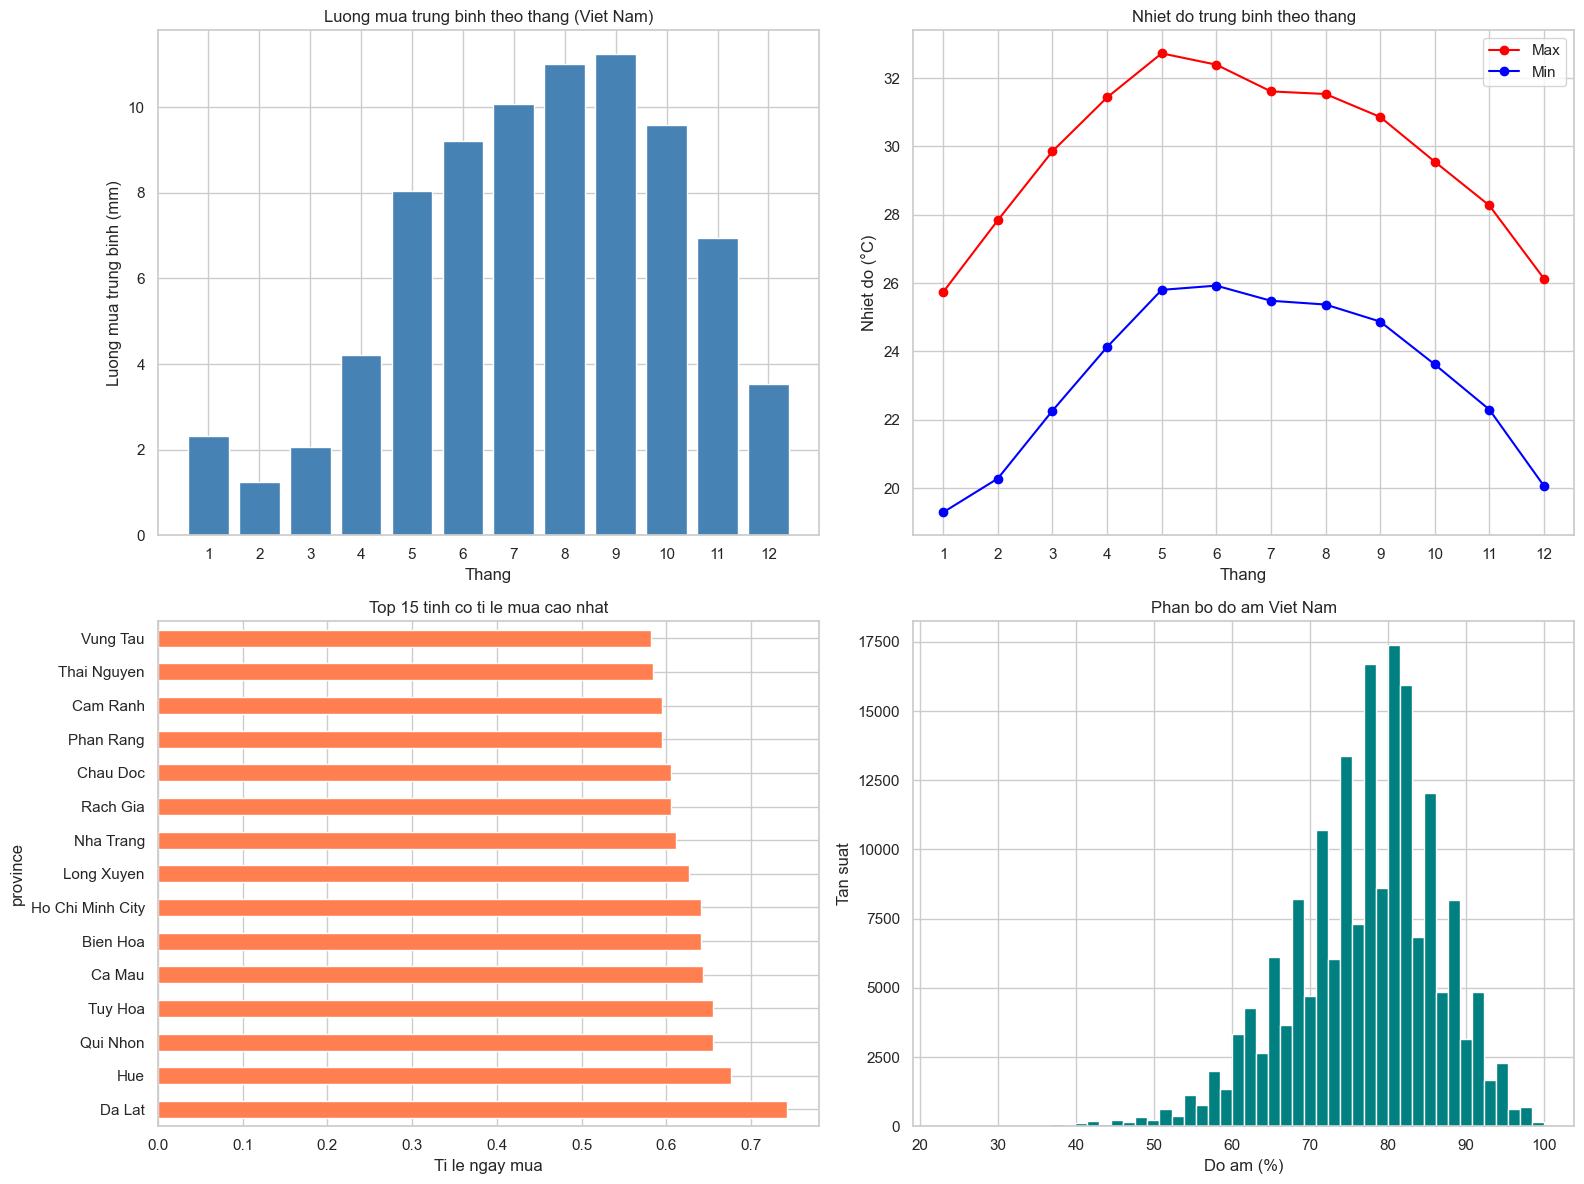

Saved: data/processed/eda_weather.png


In [51]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 3.1a: Phan bo luong mua theo thang
if 'month' in df_weather.columns and 'rain_mm' in df_weather.columns:
    monthly_rain = df_weather.groupby('month')['rain_mm'].mean()
    axes[0, 0].bar(monthly_rain.index, monthly_rain.values, color='steelblue')
    axes[0, 0].set_xlabel('Thang')
    axes[0, 0].set_ylabel('Luong mua trung binh (mm)')
    axes[0, 0].set_title('Luong mua trung binh theo thang (Viet Nam)')
    axes[0, 0].set_xticks(range(1, 13))

# 3.1b: Nhiet do trung binh theo thang
if 'month' in df_weather.columns and 'temp_max' in df_weather.columns:
    monthly_temp = df_weather.groupby('month')[['temp_max', 'temp_min']].mean()
    axes[0, 1].plot(monthly_temp.index, monthly_temp['temp_max'], 'r-o', label='Max')
    axes[0, 1].plot(monthly_temp.index, monthly_temp['temp_min'], 'b-o', label='Min')
    axes[0, 1].set_xlabel('Thang')
    axes[0, 1].set_ylabel('Nhiet do (°C)')
    axes[0, 1].set_title('Nhiet do trung binh theo thang')
    axes[0, 1].legend()
    axes[0, 1].set_xticks(range(1, 13))

# 3.1c: Ti le ngay mua theo tinh (top 15)
if 'province' in df_weather.columns and 'is_rainy' in df_weather.columns:
    rain_by_prov = df_weather.groupby('province')['is_rainy'].mean().sort_values(ascending=False).head(15)
    rain_by_prov.plot(kind='barh', ax=axes[1, 0], color='coral')
    axes[1, 0].set_xlabel('Ti le ngay mua')
    axes[1, 0].set_title('Top 15 tinh co ti le mua cao nhat')

# 3.1d: Phan bo do am
if 'humidity' in df_weather.columns:
    axes[1, 1].hist(df_weather['humidity'].dropna(), bins=50, color='teal', edgecolor='white')
    axes[1, 1].set_xlabel('Do am (%)')
    axes[1, 1].set_ylabel('Tan suat')
    axes[1, 1].set_title('Phan bo do am Viet Nam')

plt.tight_layout()
plt.savefig('data/processed/eda_weather.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: data/processed/eda_weather.png')

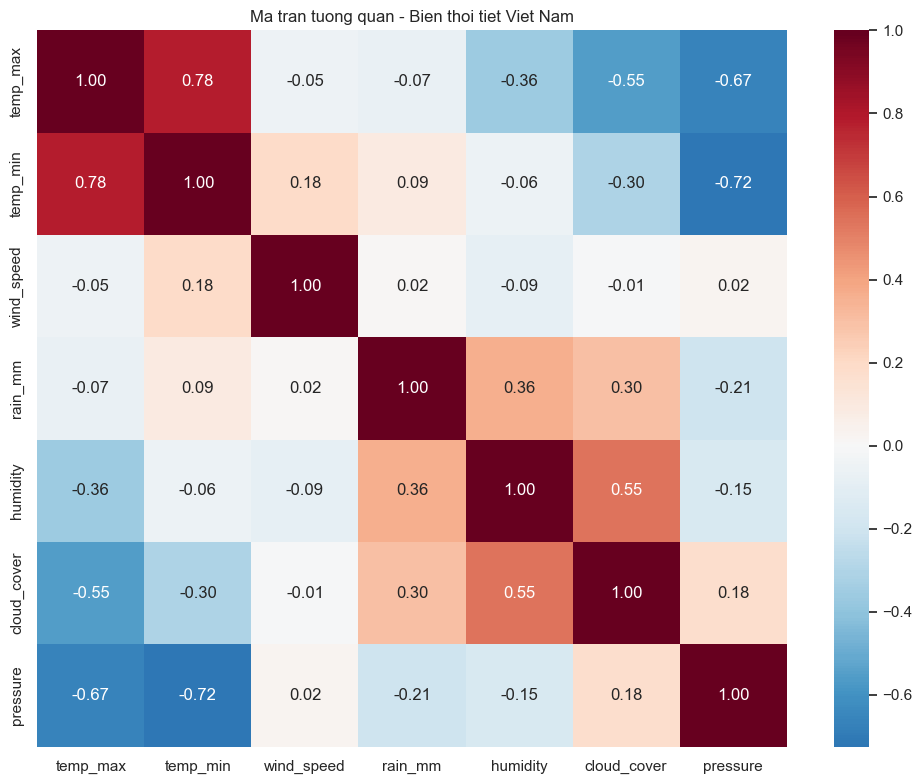

In [52]:
# Correlation matrix cua cac bien thoi tiet
weather_num_cols = ['temp_max', 'temp_min', 'wind_speed', 'rain_mm', 'humidity', 'cloud_cover', 'pressure']
weather_num_cols = [c for c in weather_num_cols if c in df_weather.columns]

if weather_num_cols:
    fig, ax = plt.subplots(figsize=(10, 8))
    corr = df_weather[weather_num_cols].corr()
    sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0, ax=ax)
    ax.set_title('Ma tran tuong quan - Bien thoi tiet Viet Nam')
    plt.tight_layout()
    plt.savefig('data/processed/eda_weather_corr.png', dpi=150, bbox_inches='tight')
    plt.show()

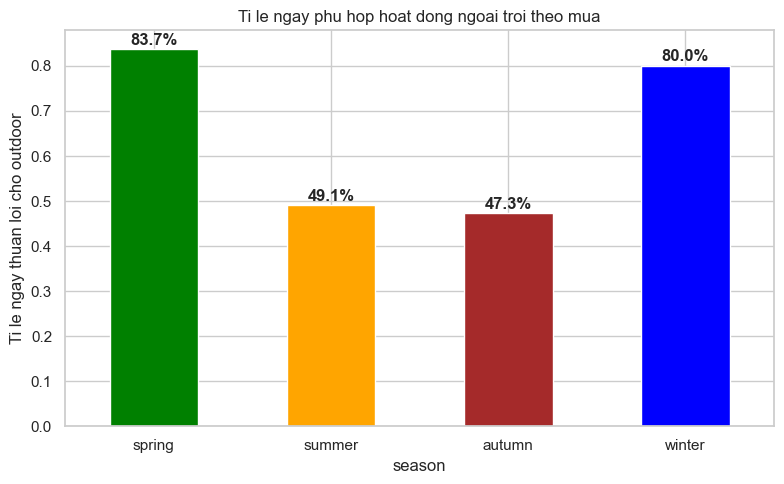

In [53]:
# Ti le outdoor_suitable theo mua
if 'season' in df_weather.columns and 'outdoor_suitable' in df_weather.columns:
    season_outdoor = df_weather.groupby('season')['outdoor_suitable'].mean()
    fig, ax = plt.subplots(figsize=(8, 5))
    season_order = ['spring', 'summer', 'autumn', 'winter']
    season_outdoor = season_outdoor.reindex(season_order)
    season_outdoor.plot(kind='bar', color=['green', 'orange', 'brown', 'blue'], ax=ax)
    ax.set_ylabel('Ti le ngay thuan loi cho outdoor')
    ax.set_title('Ti le ngay phu hop hoat dong ngoai troi theo mua')
    ax.set_xticklabels(season_order, rotation=0)
    for i, v in enumerate(season_outdoor.values):
        ax.text(i, v + 0.01, f'{v:.1%}', ha='center', fontweight='bold')
    plt.tight_layout()
    plt.savefig('data/processed/eda_outdoor_season.png', dpi=150, bbox_inches='tight')
    plt.show()

### 3.2 Hotel Reviews - Review Analysis

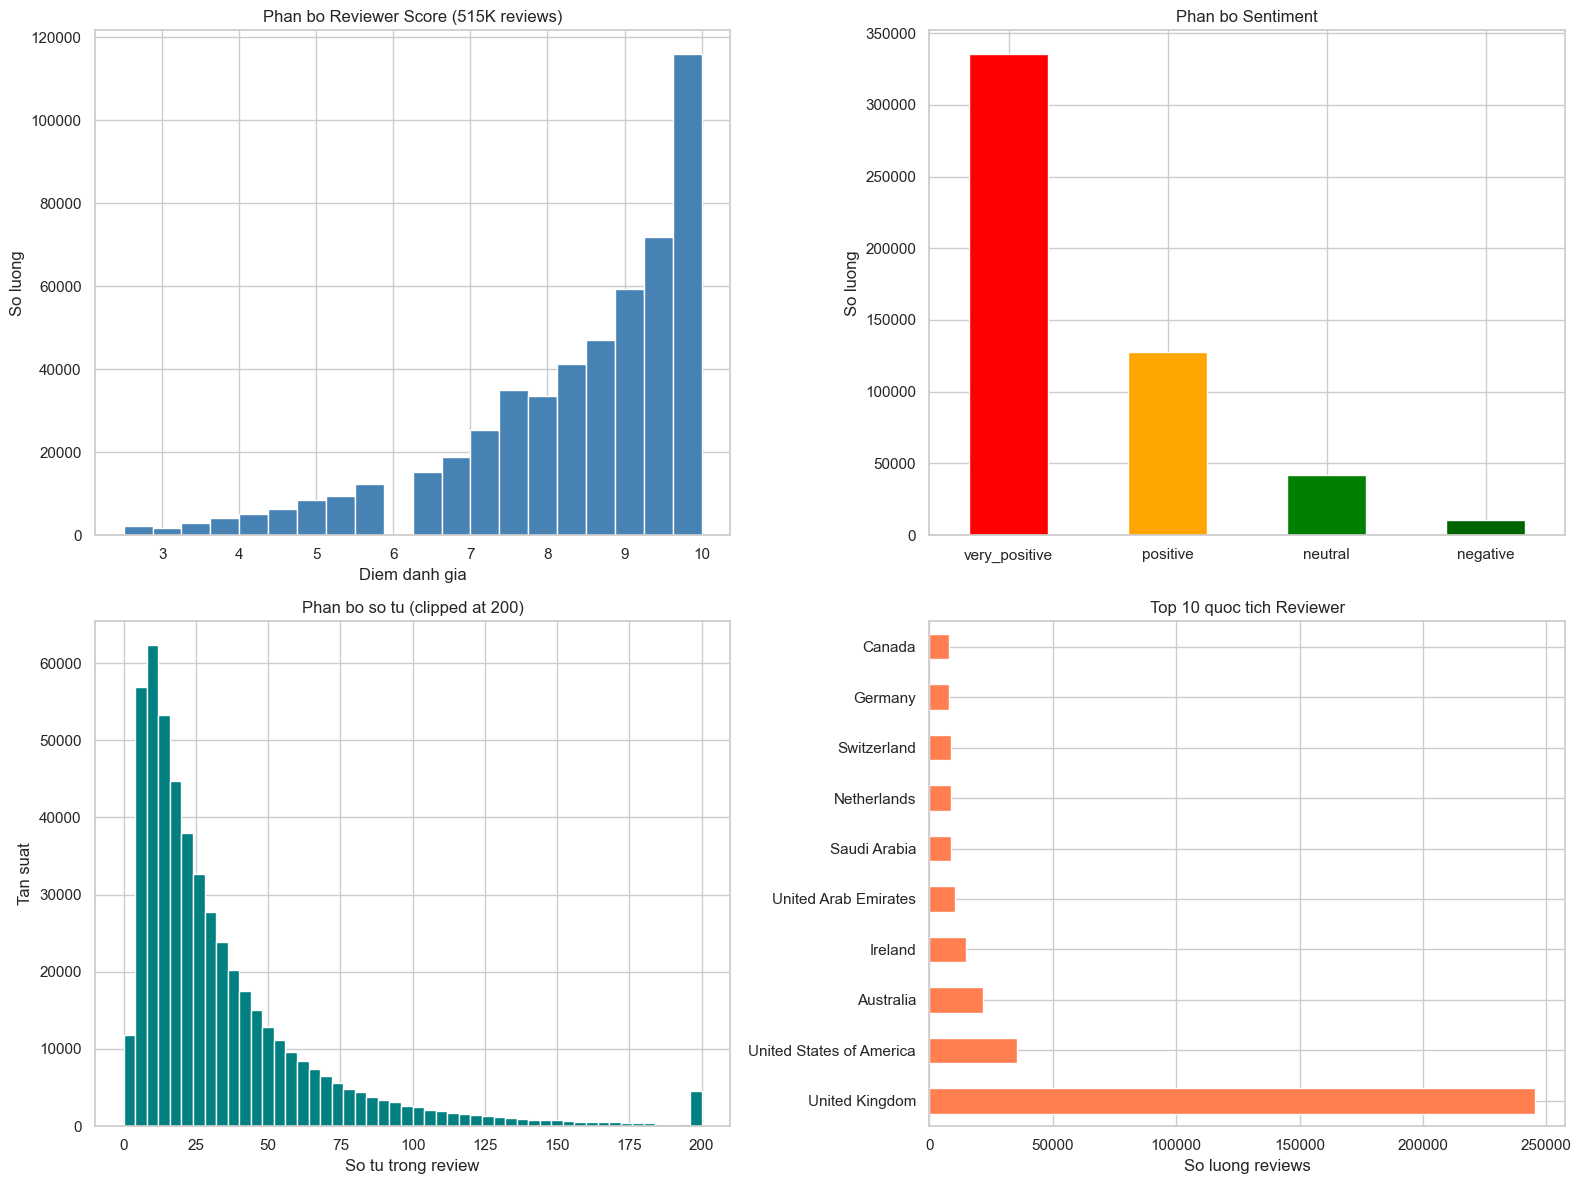

Saved: data/processed/eda_reviews.png


In [54]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 3.2a: Phan bo diem danh gia
if 'Reviewer_Score' in df_reviews.columns:
    axes[0, 0].hist(df_reviews['Reviewer_Score'].dropna(), bins=20, color='steelblue', edgecolor='white')
    axes[0, 0].set_xlabel('Diem danh gia')
    axes[0, 0].set_ylabel('So luong')
    axes[0, 0].set_title('Phan bo Reviewer Score (515K reviews)')

# 3.2b: Sentiment distribution
if 'sentiment' in df_reviews.columns:
    sent_counts = df_reviews['sentiment'].value_counts()
    sent_counts.plot(kind='bar', color=['red', 'orange', 'green', 'darkgreen'], ax=axes[0, 1])
    axes[0, 1].set_title('Phan bo Sentiment')
    axes[0, 1].set_ylabel('So luong')
    axes[0, 1].set_xticklabels(sent_counts.index, rotation=0)

# 3.2c: Phan bo so tu trong review
if 'review_word_count' in df_reviews.columns:
    axes[1, 0].hist(df_reviews['review_word_count'].clip(upper=200), bins=50, color='teal', edgecolor='white')
    axes[1, 0].set_xlabel('So tu trong review')
    axes[1, 0].set_ylabel('Tan suat')
    axes[1, 0].set_title('Phan bo so tu (clipped at 200)')

# 3.2d: Top 10 quoc tich reviewer
if 'Reviewer_Nationality' in df_reviews.columns:
    top_nations = df_reviews['Reviewer_Nationality'].str.strip().value_counts().head(10)
    top_nations.plot(kind='barh', color='coral', ax=axes[1, 1])
    axes[1, 1].set_xlabel('So luong reviews')
    axes[1, 1].set_title('Top 10 quoc tich Reviewer')

plt.tight_layout()
plt.savefig('data/processed/eda_reviews.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: data/processed/eda_reviews.png')

### 3.3 Travel Ratings - User Preference Analysis

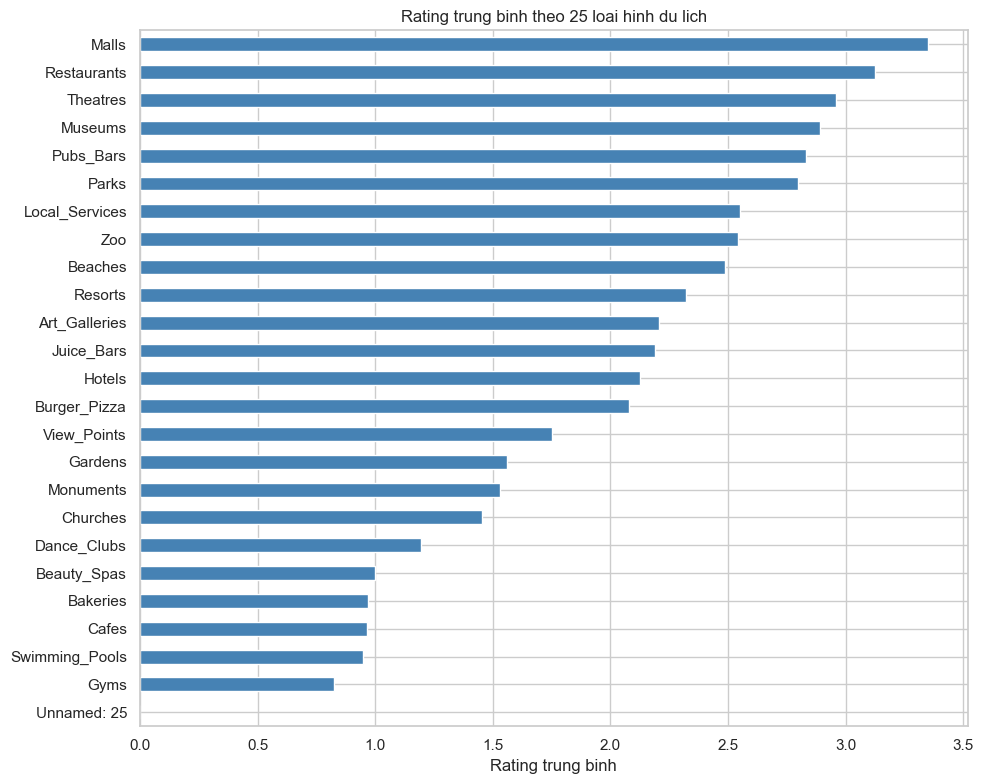

In [55]:
# Rating trung binh theo loai hinh
category_cols = [c for c in df_ratings.columns if c not in [
    'User', 'User Id', 'Unnamed: 0', 'top_category', 'avg_rating', 'rating_std', 'num_rated'
]]
# Chi lay cot co kieu so
category_cols = [c for c in category_cols if df_ratings[c].dtype in ['float64', 'int64']]

if category_cols:
    avg_by_cat = df_ratings[category_cols].mean().sort_values(ascending=True)
    fig, ax = plt.subplots(figsize=(10, 8))
    avg_by_cat.plot(kind='barh', color='steelblue', ax=ax)
    ax.set_xlabel('Rating trung binh')
    ax.set_title(f'Rating trung binh theo {len(category_cols)} loai hinh du lich')
    plt.tight_layout()
    plt.savefig('data/processed/eda_ratings.png', dpi=150, bbox_inches='tight')
    plt.show()

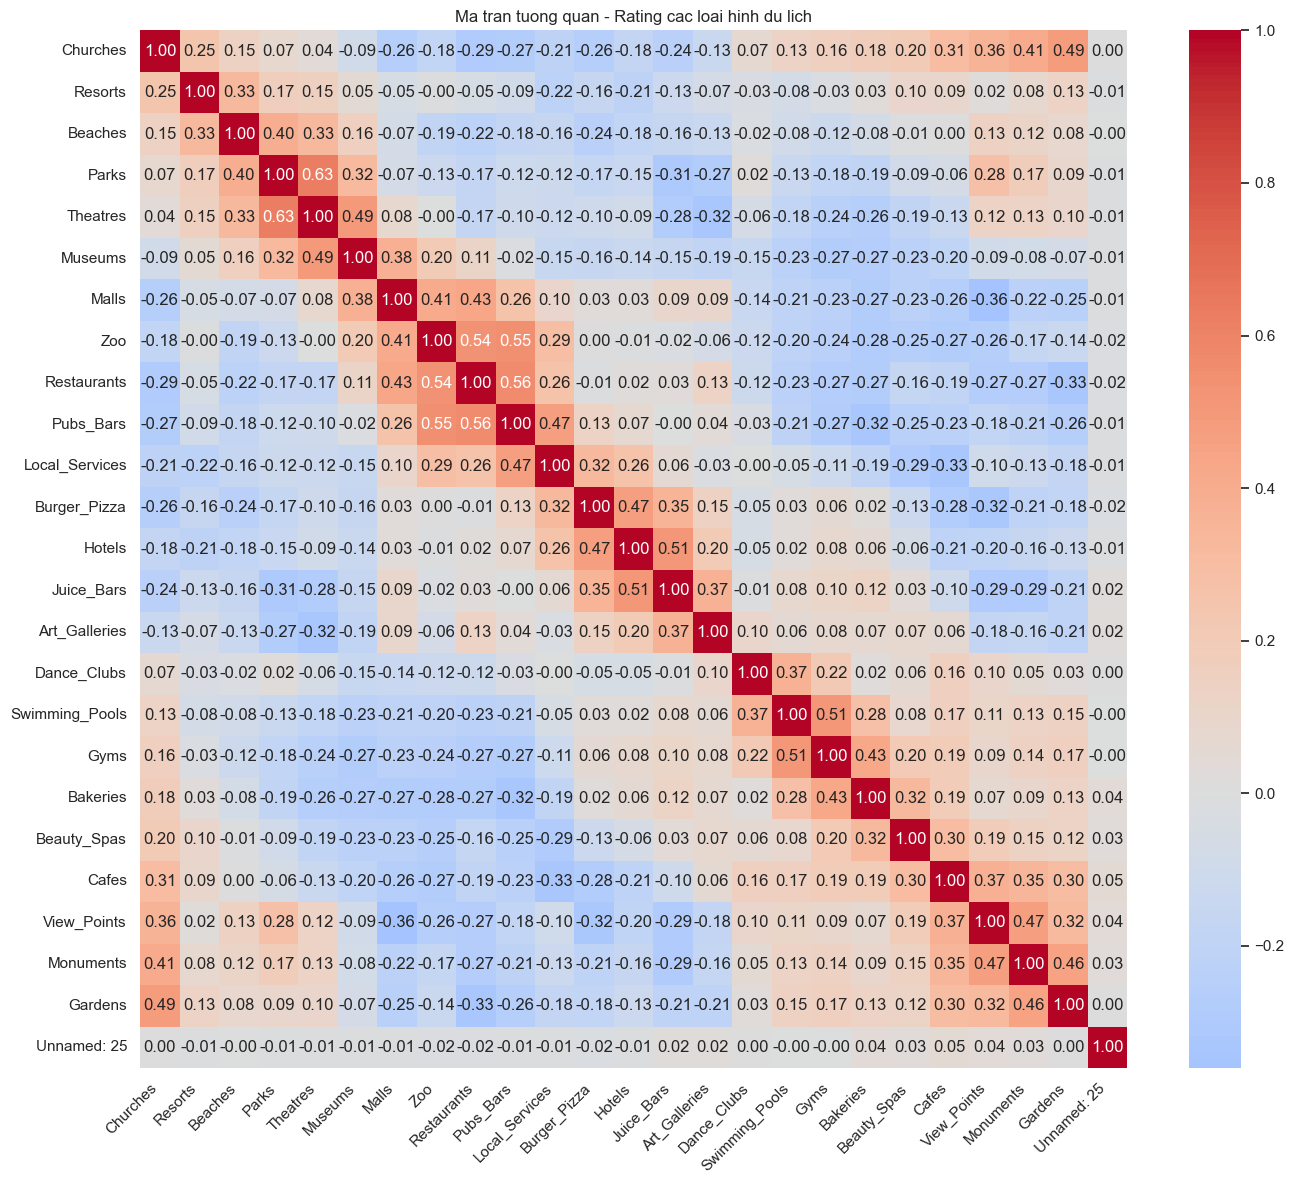

In [56]:
# Correlation heatmap cua cac loai hinh
if len(category_cols) >= 5:
    fig, ax = plt.subplots(figsize=(14, 12))
    corr = df_ratings[category_cols].corr()
    sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
                ax=ax, xticklabels=True, yticklabels=True)
    ax.set_title('Ma tran tuong quan - Rating cac loai hinh du lich')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.savefig('data/processed/eda_ratings_corr.png', dpi=150, bbox_inches='tight')
    plt.show()

### 3.4 Hotel Bookings - Booking Analysis

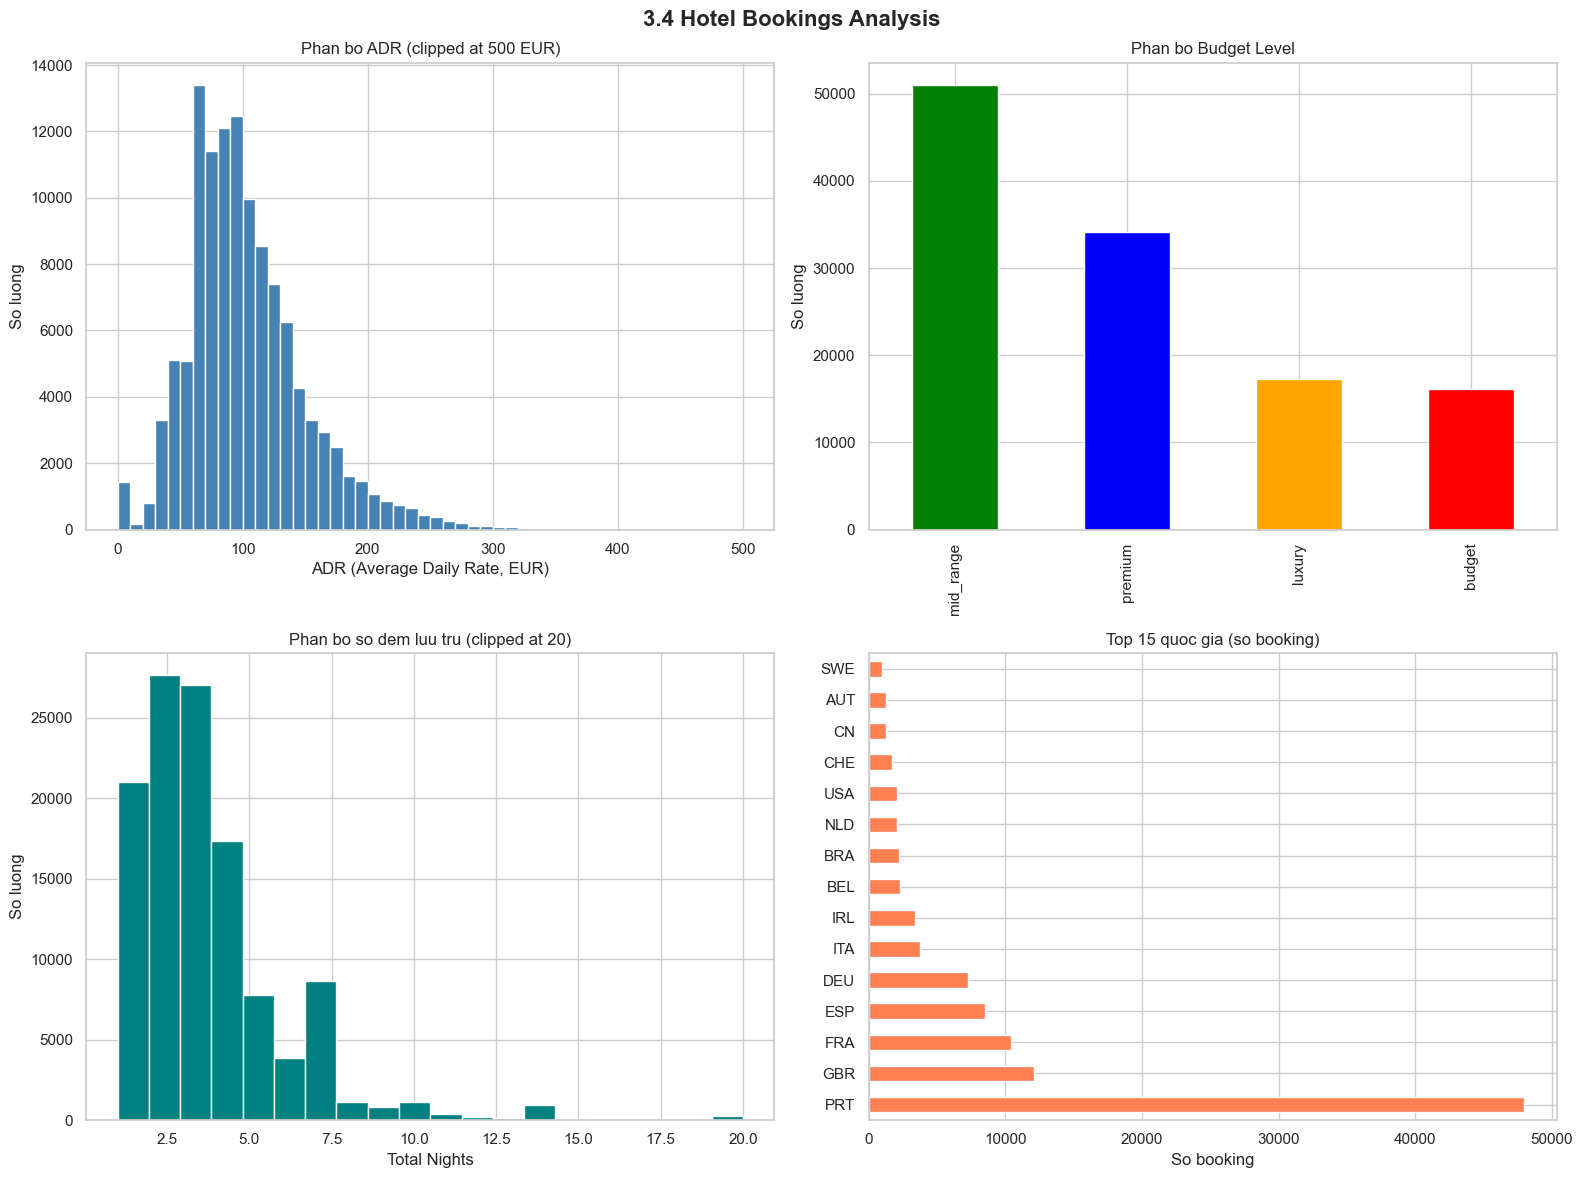

In [57]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 3.4a: ADR distribution
if 'adr' in df_bookings.columns:
    axes[0, 0].hist(df_bookings['adr'].clip(upper=500), bins=50, color='steelblue', edgecolor='white')
    axes[0, 0].set_xlabel('ADR (Average Daily Rate, EUR)')
    axes[0, 0].set_ylabel('So luong')
    axes[0, 0].set_title('Phan bo ADR (clipped at 500 EUR)')

# 3.4b: Budget level distribution
if 'budget_level' in df_bookings.columns:
    budget_counts = df_bookings['budget_level'].value_counts()
    budget_counts.plot(kind='bar', color=['green', 'blue', 'orange', 'red'], ax=axes[0, 1])
    axes[0, 1].set_title('Phan bo Budget Level')
    axes[0, 1].set_ylabel('So luong')

# 3.4c: Total nights distribution
if 'total_nights' in df_bookings.columns:
    axes[1, 0].hist(df_bookings['total_nights'].clip(upper=20), bins=20, color='teal', edgecolor='white')
    axes[1, 0].set_xlabel('Total Nights')
    axes[1, 0].set_ylabel('So luong')
    axes[1, 0].set_title('Phan bo so dem luu tru (clipped at 20)')

# 3.4d: Top 15 countries
if 'country' in df_bookings.columns:
    top_countries = df_bookings['country'].value_counts().head(15)
    top_countries.plot(kind='barh', color='coral', ax=axes[1, 1])
    axes[1, 1].set_title('Top 15 quoc gia (so booking)')
    axes[1, 1].set_xlabel('So booking')

fig.suptitle('3.4 Hotel Bookings Analysis', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(PROCESSED_DIR, "eda_hotel_bookings.png"), dpi=150, bbox_inches="tight")
plt.show()

---
## 4. Feature Engineering

### 4.1 Distance Matrix - Vietnam Tourist Spots
Used for (A) A* and (B) CSP

In [58]:
# Build & save distance matrix
place_names, dist_matrix = build_distance_matrix()
save_features(dist_matrix, 'distance_matrix')

# Hien thi
df_dist = pd.DataFrame(dist_matrix, index=place_names, columns=place_names)
print(f'Ma tran khoang cach: {dist_matrix.shape[0]} x {dist_matrix.shape[1]} diem')
print(f'Khoang cach min (> 0): {dist_matrix[dist_matrix > 0].min():.1f} km')
print(f'Khoang cach max: {dist_matrix.max():.1f} km')
df_dist.head(10)

[FEATURE] Distance matrix: 30x30 places
[SAVE] /Users/nhanhoang/Desktop/Introduction-AI-Assignment/data/features/distance_matrix.npy (shape: (30, 30))
Ma tran khoang cach: 30 x 30 diem
Khoang cach min (> 0): 0.4 km
Khoang cach max: 1353.1 km


,Ha Long Bay,Hoan Kiem Lake,Temple of Literature,Ho Chi Minh Mausoleum,Old Quarter Hanoi,Imperial City Hue,Marble Mountains,Golden Bridge,My Son Sanctuary,Hoi An Ancient Town,Cu Chi Tunnels,Ben Thanh Market,Notre Dame Cathedral HCMC,War Remnants Museum,Nha Trang Beach,Vinpearl Nha Trang,Po Nagar Towers,Xuan Huong Lake,Crazy House Da Lat,Valley of Love,Mui Ne Sand Dunes,Phu Quoc Beach,Sapa,Fansipan Summit,Trang An Landscape,Bai Dinh Pagoda,Phong Nha Cave,Son Doong Cave,Cat Ba Island,Ba Na Hills
Ha Long Bay,0.00,138.87,140.56,140.76,139.18,495.48,557.33,553.33,580.71,572.40,1088.94,1128.44,1127.63,1127.71,986.88,990.99,984.79,1005.72,1006.64,1003.48,1115.60,1229.46,379.93,384.95,152.48,154.54,380.87,388.57,24.94,552.93
Hoan Kiem Lake,138.87,0.00,1.72,2.03,0.63,538.51,613.83,603.74,632.50,629.63,1101.34,1144.02,1143.21,1143.20,1039.34,1043.84,1037.31,1046.90,1047.66,1044.69,1152.24,1210.69,253.40,257.24,86.74,84.04,384.82,387.43,128.45,603.36
Temple of Literature,140.56,1.72,0.00,1.05,1.62,538.96,614.42,604.26,633.03,630.22,1101.30,1144.01,1143.21,1143.20,1039.81,1044.32,1037.78,1047.22,1047.98,1045.02,1152.50,1210.26,252.09,255.90,86.71,83.94,384.88,387.43,130.07,603.88
Ho Chi Minh Mausoleum,140.76,2.03,1.05,0.00,1.59,539.98,615.41,605.27,634.03,631.21,1102.35,1145.06,1144.26,1144.25,1040.83,1045.33,1038.80,1048.26,1049.02,1046.05,1153.54,1211.27,251.40,255.23,87.76,84.99,385.93,388.48,130.43,604.89
Old Quarter Hanoi,139.18,0.63,1.62,1.59,0.00,539.14,614.46,604.38,633.13,630.26,1101.94,1144.61,1143.81,1143.80,1039.98,1044.48,1037.95,1047.52,1048.29,1045.32,1152.86,1211.22,252.86,256.70,87.33,84.62,385.43,388.03,128.85,604.00
Imperial City Hue,495.48,538.51,538.96,539.98,539.14,0.00,89.58,69.24,97.71,104.29,604.60,640.61,639.79,639.95,500.88,505.41,498.86,511.54,512.40,509.31,620.36,789.46,760.77,761.40,456.13,459.95,185.82,194.31,476.66,68.90
Marble Mountains,557.33,613.83,614.42,615.41,614.46,89.58,0.00,28.44,30.44,15.89,574.54,605.76,604.95,605.20,429.70,433.89,427.62,451.57,452.60,449.34,563.78,786.17,843.20,844.17,534.12,538.14,274.94,283.79,540.67,28.48
Golden Bridge,553.33,603.74,604.26,605.27,604.38,69.24,28.44,0.00,28.93,38.61,564.47,597.35,596.54,596.76,436.31,440.69,434.25,452.66,453.62,450.43,563.60,768.72,829.07,829.81,522.53,526.45,254.64,262.58,535.73,0.39
My Son Sanctuary,580.71,632.50,633.03,634.03,633.13,97.71,30.44,28.93,0.00,26.25,544.52,576.12,575.31,575.55,407.91,412.26,405.85,425.96,426.95,423.73,537.48,756.00,857.96,858.68,551.41,555.34,282.37,289.89,563.40,29.30
Hoi An Ancient Town,572.40,629.63,630.22,631.21,630.26,104.29,15.89,38.61,26.25,0.00,564.55,594.99,594.19,594.46,414.51,418.66,412.42,437.59,438.65,435.36,550.09,780.10,859.08,860.04,549.99,554.02,289.99,298.60,555.90,38.79


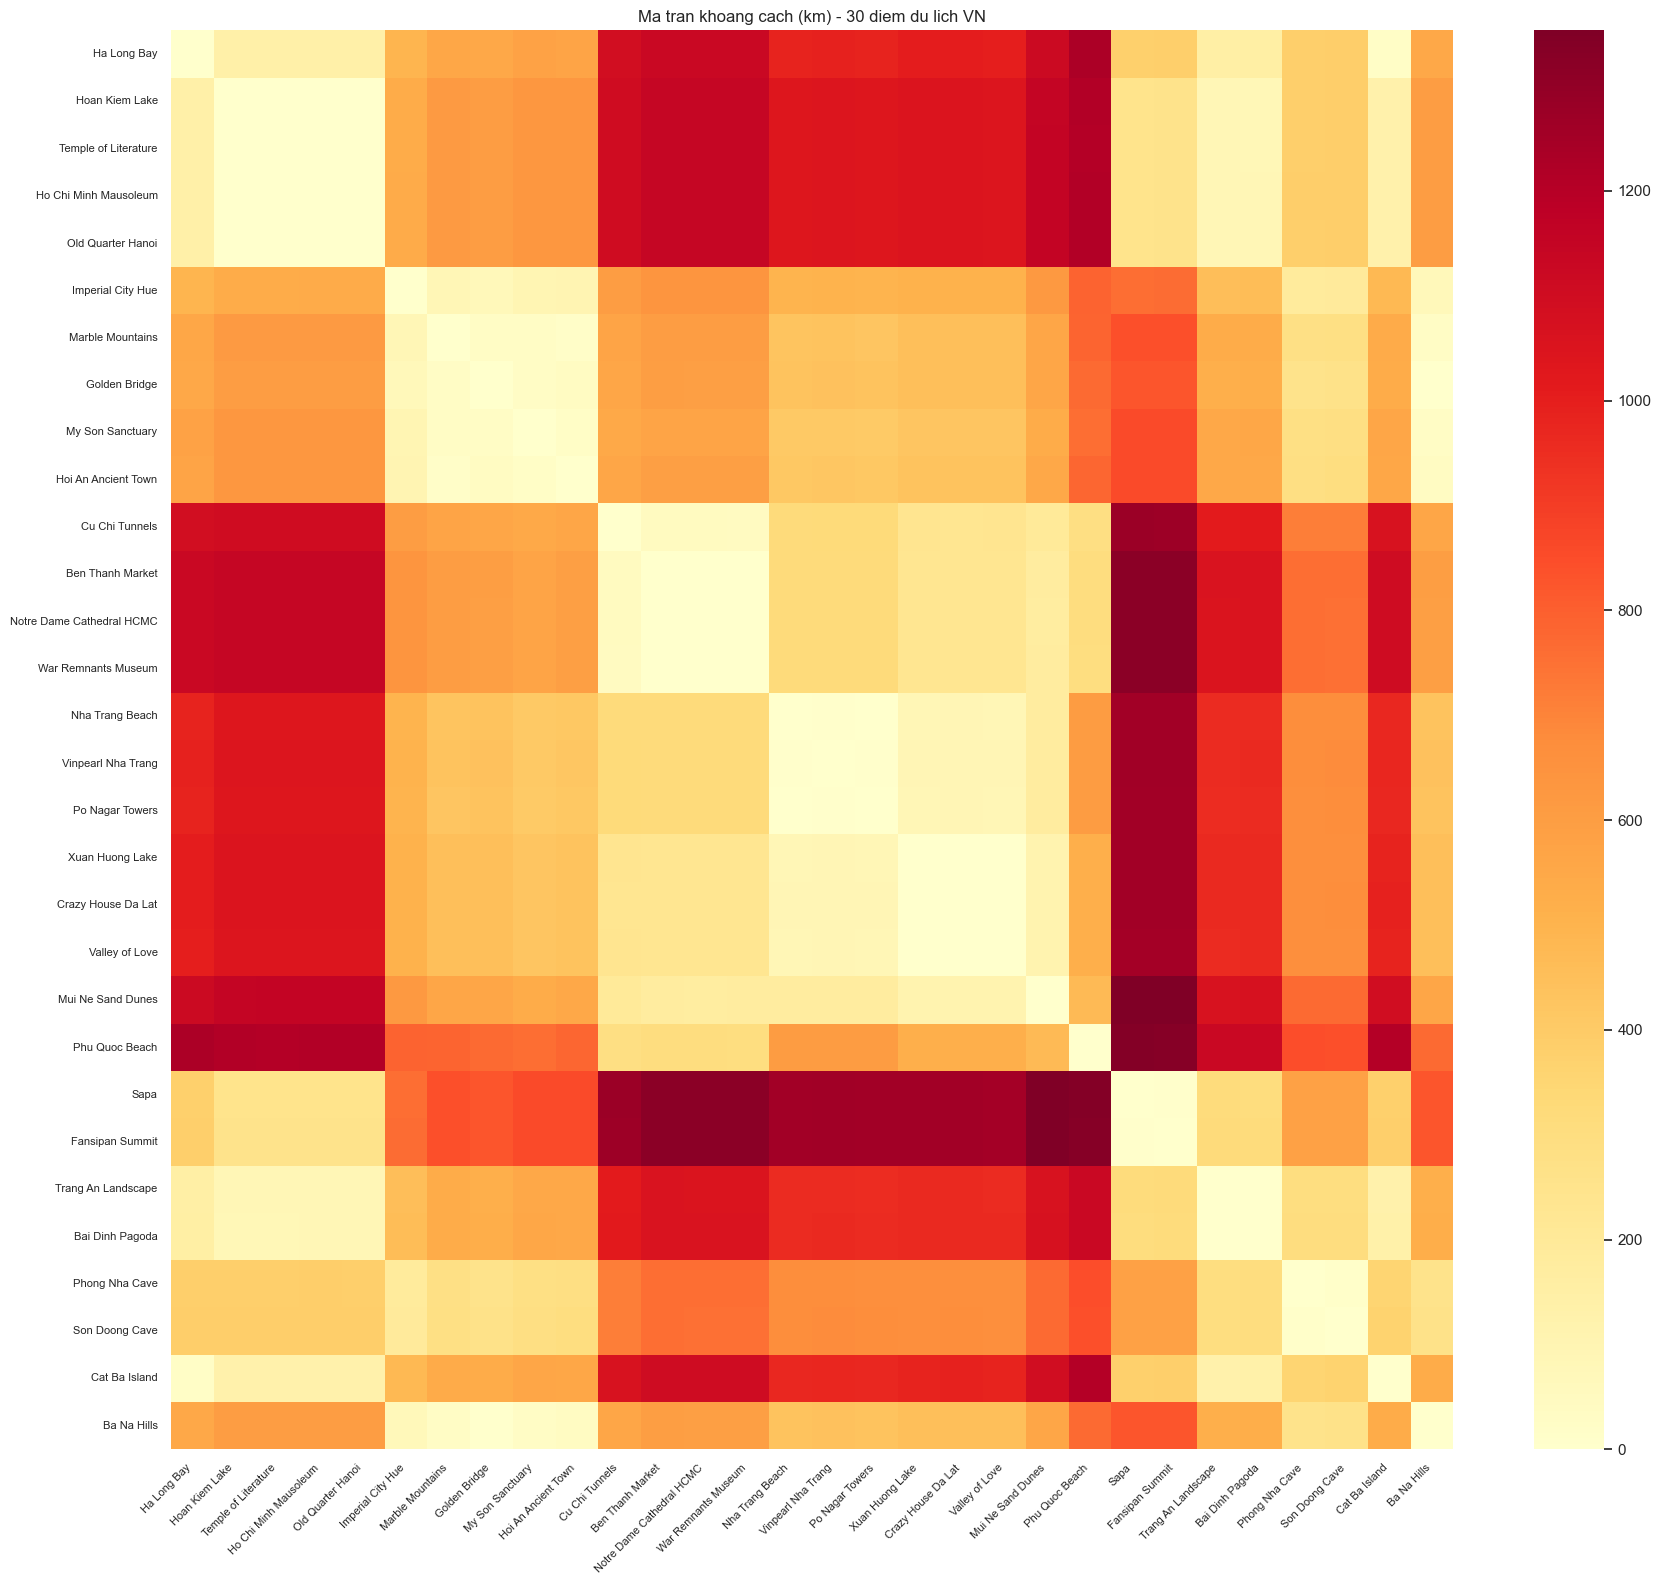

In [59]:
# Visualize distance matrix (heatmap)
fig, ax = plt.subplots(figsize=(18, 16))
sns.heatmap(df_dist, cmap='YlOrRd', ax=ax, fmt='.0f',
            xticklabels=True, yticklabels=True)
ax.set_title(f'Ma tran khoang cach (km) - {len(place_names)} diem du lich VN')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.savefig('data/processed/distance_matrix_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

In [60]:
# Cost matrix & Travel time matrix
_, cost_matrix = build_cost_matrix()
save_features(cost_matrix, 'cost_matrix')

_, time_matrix = build_travel_time_matrix()
save_features(time_matrix, 'travel_time_matrix')

print(f'Cost matrix range: {cost_matrix[cost_matrix > 0].min():,.0f} - {cost_matrix.max():,.0f} VND')
print(f'Time matrix range: {time_matrix[time_matrix > 0].min():.1f} - {time_matrix.max():.1f} hours')

[FEATURE] Distance matrix: 30x30 places
[FEATURE] Cost matrix: 30x30 places (VND)
[SAVE] /Users/nhanhoang/Desktop/Introduction-AI-Assignment/data/features/cost_matrix.npy (shape: (30, 30))
[FEATURE] Distance matrix: 30x30 places
[FEATURE] Travel time matrix: 30x30 places (hours)
[SAVE] /Users/nhanhoang/Desktop/Introduction-AI-Assignment/data/features/travel_time_matrix.npy (shape: (30, 30))
Cost matrix range: 1,170 - 4,059,270 VND
Time matrix range: 0.0 - 33.8 hours


### 4.2 Places DataFrame - Tourist Spot Information

In [61]:
df_places = build_places_dataframe()
save_feature_csv(df_places, 'vn_tourist_places')

print(f'\nSo diem du lich: {len(df_places)}')
print(f'\nPhan bo theo category:')
print(df_places['category'].value_counts())
print(f'\nPhan bo theo tinh:')
print(df_places['province'].value_counts())
df_places

[FEATURE] Places DataFrame: 30 places
[SAVE] /Users/nhanhoang/Desktop/Introduction-AI-Assignment/data/features/vn_tourist_places.csv (30 rows)

So diem du lich: 30

Phan bo theo category:
culture          14
nature           10
beach             2
entertainment     2
adventure         2
Name: category, dtype: int64

Phan bo theo tinh:
Ha Noi         4
Ho Chi Minh    4
Da Nang        3
Khanh Hoa      3
Lam Dong       3
Quang Nam      2
Lao Cai        2
Ninh Binh      2
Quang Binh     2
Quang Ninh     1
Hue            1
Binh Thuan     1
Kien Giang     1
Hai Phong      1
Name: province, dtype: int64


,place_name,latitude,longitude,category,province,entry_fee_vnd,visit_duration_hours,opening_hour,closing_hour
0,Ha Long Bay,20.9101,107.1839,nature,Quang Ninh,0,3.0,7,17
1,Hoan Kiem Lake,21.0288,105.8525,culture,Ha Noi,0,2.0,7,17
2,Temple of Literature,21.0275,105.8360,culture,Ha Noi,30000,2.0,7,17
3,Ho Chi Minh Mausoleum,21.0369,105.8350,culture,Ha Noi,0,2.0,7,17
4,Old Quarter Hanoi,21.0340,105.8500,culture,Ha Noi,0,2.0,7,17
5,Imperial City Hue,16.4698,107.5786,culture,Hue,200000,2.0,7,17
6,Marble Mountains,16.0034,108.2628,nature,Da Nang,40000,3.0,7,17
7,Golden Bridge,15.9940,107.9969,nature,Da Nang,900000,3.0,7,17
8,My Son Sanctuary,15.7644,108.1241,culture,Quang Nam,150000,2.0,7,17
9,Hoi An Ancient Town,15.8801,108.3380,culture,Quang Nam,120000,2.0,7,17


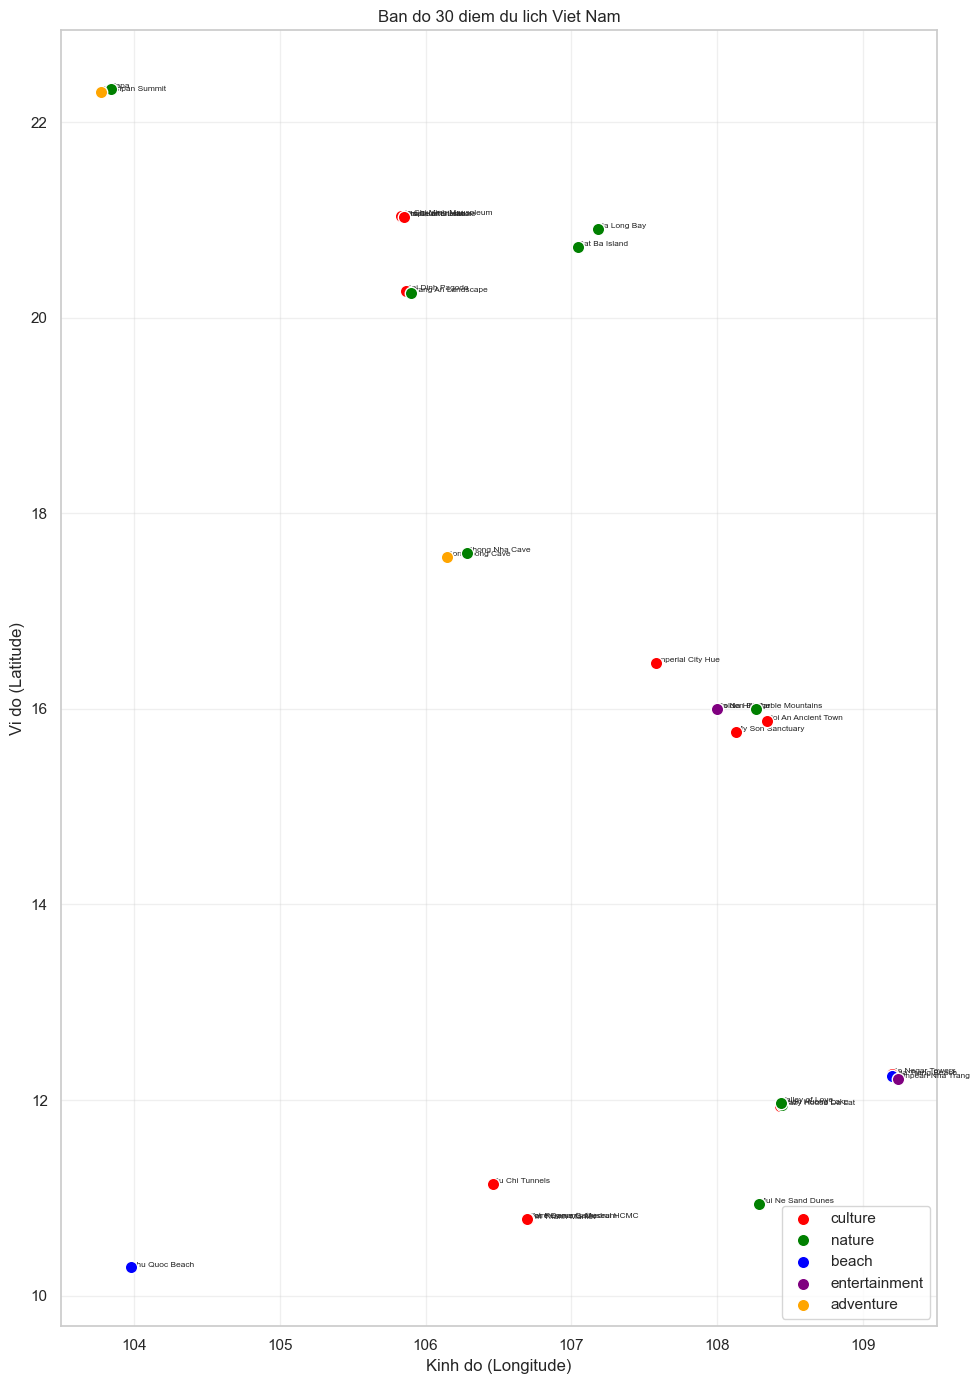

In [62]:
# Map cac diem du lich (scatter plot)
fig, ax = plt.subplots(figsize=(10, 14))
colors = {'culture': 'red', 'nature': 'green', 'beach': 'blue',
          'entertainment': 'purple', 'adventure': 'orange'}
for cat, color in colors.items():
    subset = df_places[df_places['category'] == cat]
    ax.scatter(subset['longitude'], subset['latitude'],
               c=color, label=cat, s=80, edgecolors='white', zorder=5)
    for _, row in subset.iterrows():
        ax.annotate(row['place_name'], (row['longitude'], row['latitude']),
                     fontsize=6, ha='left', va='bottom')

ax.set_xlabel('Kinh do (Longitude)')
ax.set_ylabel('Vi do (Latitude)')
ax.set_title(f'Ban do {len(df_places)} diem du lich Viet Nam')
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('data/processed/places_map.png', dpi=150, bbox_inches='tight')
plt.show()

### 4.3 Weather Probability Table - For Bayesian Network

In [63]:
weather_probs = build_weather_probability_table(df_weather)
save_feature_csv(weather_probs, 'weather_probabilities')

print(f'\nBang xac suat: {weather_probs.shape[0]} dong (tinh x thang)')
print(f'\nVi du - Ha Noi:')
weather_probs[weather_probs['province'].str.contains('Ha Noi|Hanoi|Ha noi', case=False, na=False)]

[FEATURE] Weather probability table: 480 rows (province x month)
[SAVE] /Users/nhanhoang/Desktop/Introduction-AI-Assignment/data/features/weather_probabilities.csv (480 rows)

Bang xac suat: 480 dong (tinh x thang)

Vi du - Ha Noi:


,province,month,p_rain,p_outdoor_ok,p_hot,p_humid
120,Ha Noi,1,0.240695,0.928040,0.000000,0.282878
121,Ha Noi,2,0.186813,0.964286,0.043956,0.219780
122,Ha Noi,3,0.270471,0.915633,0.039702,0.272953
123,Ha Noi,4,0.451282,0.779487,0.148718,0.407692
124,Ha Noi,5,0.602978,0.461538,0.399504,0.250620
125,Ha Noi,6,0.711640,0.410053,0.582011,0.171958
126,Ha Noi,7,0.795699,0.387097,0.387097,0.381720
127,Ha Noi,8,0.793011,0.440860,0.282258,0.510753
128,Ha Noi,9,0.683333,0.577778,0.091667,0.508333
129,Ha Noi,10,0.427419,0.803763,0.010753,0.268817


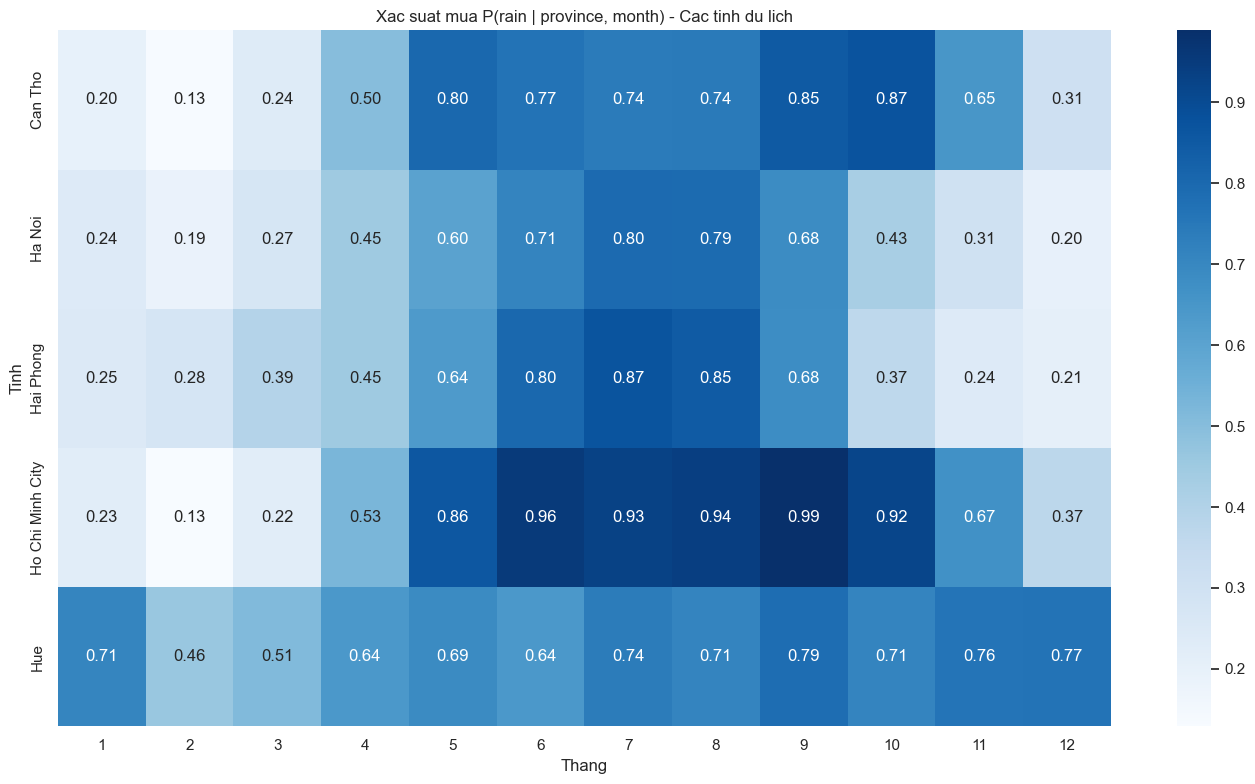

In [64]:
# Heatmap xac suat mua theo tinh x thang (top 15 tinh du lich)
tourist_provinces = ['Ha Noi', 'Ho Chi Minh', 'Da Nang', 'Hue',
                     'Khanh Hoa', 'Lam Dong', 'Quang Ninh', 'Quang Binh',
                     'Quang Nam', 'Binh Thuan', 'Kien Giang', 'Lao Cai',
                     'Ninh Binh', 'Hai Phong', 'Can Tho']

# Tim cac tinh co trong du lieu
available_provinces = []
for tp in tourist_provinces:
    matches = weather_probs[weather_probs['province'].str.contains(tp, case=False, na=False)]
    if len(matches) > 0:
        available_provinces.append(matches['province'].iloc[0])

if available_provinces:
    subset = weather_probs[weather_probs['province'].isin(available_provinces)]
    pivot = subset.pivot_table(index='province', columns='month', values='p_rain')

    fig, ax = plt.subplots(figsize=(14, 8))
    sns.heatmap(pivot, annot=True, fmt='.2f', cmap='Blues', ax=ax)
    ax.set_title('Xac suat mua P(rain | province, month) - Cac tinh du lich')
    ax.set_xlabel('Thang')
    ax.set_ylabel('Tinh')
    plt.tight_layout()
    plt.savefig('data/processed/weather_rain_prob_heatmap.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('Khong tim thay tinh du lich trong du lieu. Kiem tra ten tinh.')

### 4.4 Text Features - From Hotel Reviews for ML

In [65]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Lay sample 50K reviews de TF-IDF (tiet kiem RAM)
if 'full_review' in df_reviews.columns:
    sample_reviews = df_reviews[['full_review', 'sentiment_binary', 'Reviewer_Score']].dropna()
    sample_reviews = sample_reviews[sample_reviews['full_review'].str.len() > 20]

    if len(sample_reviews) > 50000:
        sample_reviews = sample_reviews.sample(50000, random_state=42)

    print(f'Sample size: {len(sample_reviews):,} reviews')

    # TF-IDF vectorization (top 5000 features)
    tfidf = TfidfVectorizer(max_features=5000, stop_words='english', ngram_range=(1, 2))
    X_tfidf = tfidf.fit_transform(sample_reviews['full_review'])

    print(f'TF-IDF matrix: {X_tfidf.shape}')
    print(f'Top 20 features: {tfidf.get_feature_names_out()[:20].tolist()}')

    # Save
    from scipy import sparse
    sparse.save_npz('data/features/review_tfidf.npz', X_tfidf)
    np.save('data/features/review_labels.npy', sample_reviews['sentiment_binary'].values)
    np.save('data/features/review_scores.npy', sample_reviews['Reviewer_Score'].values)

    # Save TF-IDF feature names
    pd.DataFrame({'feature': tfidf.get_feature_names_out()}).to_csv(
        'data/features/tfidf_features.csv', index=False)

    print(f'\nSaved:')
    print(f'  data/features/review_tfidf.npz ({X_tfidf.shape})')
    print(f'  data/features/review_labels.npy ({len(sample_reviews):,})')
    print(f'  data/features/review_scores.npy ({len(sample_reviews):,})')
else:
    print('Cot full_review khong ton tai. Kiem tra lai.')

Sample size: 50,000 reviews
TF-IDF matrix: (50000, 5000)
Top 20 features: ['00', '00am', '00pm', '02', '10', '10 10', '10 15', '10 30', '10 min', '10 mins', '10 minute', '10 minutes', '100', '10am', '10pm', '11', '11am', '11pm', '12', '13']

Saved:
  data/features/review_tfidf.npz ((50000, 5000))
  data/features/review_labels.npy (50,000)
  data/features/review_scores.npy (50,000)


### 4.5 User Feature Vectors - From Travel Ratings for User Classification

In [66]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Lay cac cot rating
cat_cols = [c for c in df_ratings.columns if c not in [
    'User', 'User Id', 'Unnamed: 0', 'top_category', 'avg_rating', 'rating_std', 'num_rated'
] and df_ratings[c].dtype in ['float64', 'int64']]

if cat_cols:
    X_ratings = df_ratings[cat_cols].values

    # Standardize
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_ratings)

    # K-Means clustering de tao nhan traveler_type
    # Chon k=5 (5 loai khach du lich)
    kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)

    df_ratings['cluster'] = labels

    # Dat ten cluster dua tren dac trung trung binh
    cluster_means = df_ratings.groupby('cluster')[cat_cols].mean()
    print('Dac trung trung binh cua cac cluster:')
    print(cluster_means.T)

    # Save
    np.save('data/features/user_features.npy', X_scaled)
    np.save('data/features/user_cluster_labels.npy', labels)
    save_cleaned(df_ratings, 'travel_ratings_clustered')

    print(f'\nPhan bo clusters:')
    print(df_ratings['cluster'].value_counts().sort_index())
    print(f'\nSaved: user_features.npy ({X_scaled.shape}), user_cluster_labels.npy ({len(labels)})')

Dac trung trung binh cua cac cluster:
cluster                0         1         2         3         4
Churches        0.708305  1.766206  2.344601  1.478314  1.171931
Resorts         1.002209  1.961897  2.864325  2.587545  2.239673
Beaches         1.645788  2.039605  2.718087  3.214542  1.972766
Parks           1.632312  2.027826  2.558852  3.966168  2.219334
Theatres        1.698527  2.009802  2.190287  4.386650  2.449062
Museums         1.737329  1.854664  1.985080  3.705518  3.054233
Malls           3.007277  2.643715  1.953719  3.390661  4.236705
Zoo             1.988236  1.954150  1.514389  2.363480  3.503213
Restaurants     2.845257  2.265534  1.999564  2.601734  4.440240
Pubs_Bars       2.915257  2.099051  1.644718  2.544054  3.808151
Local_Services  3.281473  2.070198  1.428831  2.383946  3.124708
Burger_Pizza    4.120223  2.052411  1.274910  1.962157  1.959629
Hotels          4.397723  2.104229  1.369373  2.016374  1.902542
Juice_Bars      4.723014  2.764348  1.637131  1.6025

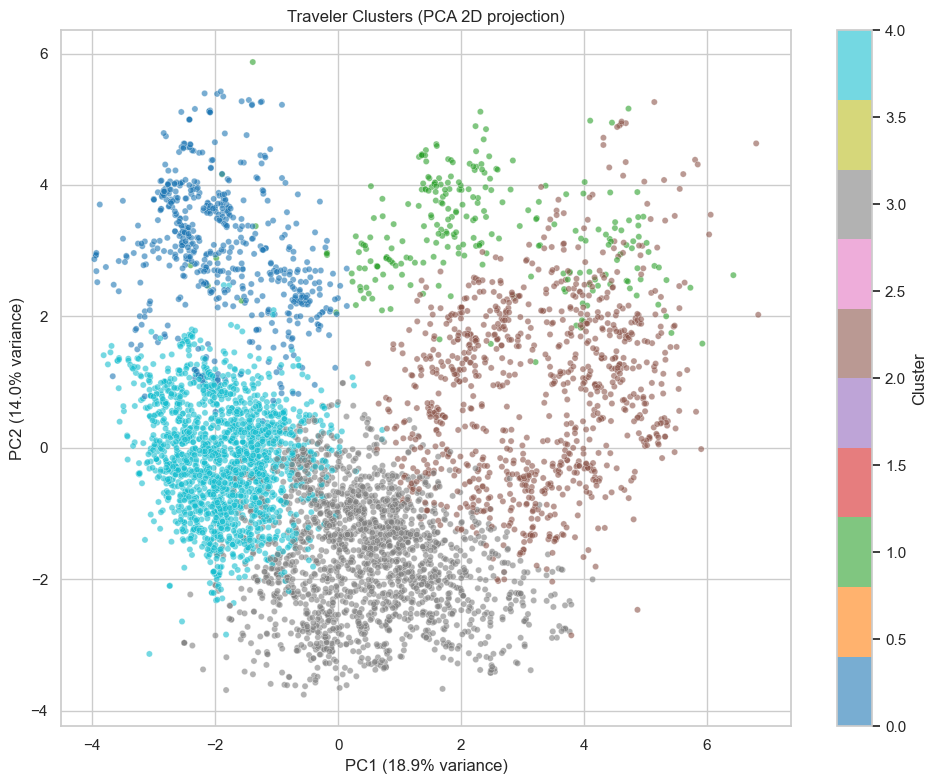

In [67]:
# Visualize clusters (PCA 2D)
from sklearn.decomposition import PCA

if 'cluster' in df_ratings.columns:
    pca = PCA(n_components=2, random_state=42)
    X_2d = pca.fit_transform(X_scaled)

    fig, ax = plt.subplots(figsize=(10, 8))
    scatter = ax.scatter(X_2d[:, 0], X_2d[:, 1], c=labels, cmap='tab10',
                          alpha=0.6, s=20, edgecolors='white', linewidth=0.3)
    ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
    ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
    ax.set_title('Traveler Clusters (PCA 2D projection)')
    plt.colorbar(scatter, label='Cluster')
    plt.tight_layout()
    plt.savefig('data/processed/user_clusters_pca.png', dpi=150, bbox_inches='tight')
    plt.show()

### 4.6 Scraped Data Enrichment (Phase 4)

Bổ sung dữ liệu từ nguồn scraped (Agoda, VN Places Detail) để làm giàu pipeline:
- **4a/4b:** Clean Agoda hotel listings & price data → `data/cleaned/`
- **4c:** VN Climate Monthly từ dữ liệu thực tế 181K records → `data/cleaned/vn_climate_monthly.csv`
- **4d:** Enrich `vn_tourist_places.csv` với mô tả tỉnh (96% coverage)
- **4e:** Hotel Price Stats theo tỉnh × tier → `data/features/hotel_price_stats.csv` (dùng cho CSP ngân sách)


In [ ]:
# === Phase 4a + 4b: Clean Agoda Hotels & Prices ===
agoda_hotels_path = os.path.join(SCRAPED_DIR, 'agoda_hotels_vn.csv')
agoda_prices_path = os.path.join(SCRAPED_DIR, 'agoda_hotel_prices_vn.csv')

df_agoda_hotels, df_agoda_prices = None, None

if os.path.exists(agoda_hotels_path):
    raw_agoda = pd.read_csv(agoda_hotels_path)
    df_agoda_hotels = clean_agoda_hotels(raw_agoda)
    save_cleaned(df_agoda_hotels, 'agoda_hotels_vn')
    print(f'[4a] Agoda Hotels: {len(df_agoda_hotels)} rows → data/cleaned/agoda_hotels_vn.csv')
else:
    print('[4a] SKIP: agoda_hotels_vn.csv not found in data/scraped/')

if os.path.exists(agoda_prices_path):
    raw_prices = pd.read_csv(agoda_prices_path)
    df_agoda_prices = clean_agoda_prices(raw_prices)
    save_cleaned(df_agoda_prices, 'agoda_hotel_prices_vn')
    print(f'[4b] Agoda Prices: {len(df_agoda_prices)} rows → data/cleaned/agoda_hotel_prices_vn.csv')
else:
    print('[4b] SKIP: agoda_hotel_prices_vn.csv not found in data/scraped/')

# === Phase 4c: VN Climate Monthly from real 181K weather records ===
df_climate = build_vn_climate_monthly(df_weather)
if not df_climate.empty:
    save_cleaned(df_climate, 'vn_climate_monthly')
    print(f'[4c] VN Climate Monthly: {len(df_climate)} rows → data/cleaned/vn_climate_monthly.csv')
    print(f'     Provinces: {df_climate["province"].nunique()}, Months: {df_climate["month"].nunique()}')
print()
if not df_climate.empty:
    df_climate.head(4)


In [ ]:
# === Phase 4d: Enrich Tourist Places with Province Descriptions ===
df_places = enrich_places_with_descriptions(df_places)
save_feature_csv(df_places, 'vn_tourist_places')

desc_count = 0
if 'description' in df_places.columns:
    desc_count = (df_places['description'].str.strip().str.len() > 30).sum()
print(f'[4d] vn_tourist_places.csv enriched: {len(df_places)} places, {desc_count}/{len(df_places)} with descriptions')

# === Phase 4e: Hotel Price Stats (province × tier) for CSP budget constraints ===
if df_agoda_prices is not None and not df_agoda_prices.empty:
    price_stats = build_hotel_price_stats(df_agoda_prices)
    if price_stats is not None:
        save_feature_csv(price_stats, 'hotel_price_stats')
        print(f'[4e] Hotel Price Stats: {len(price_stats)} rows → data/features/hotel_price_stats.csv')
        print(f'     Provinces: {price_stats["province"].nunique()}, Tiers: {price_stats["price_tier"].unique().tolist()}')
        print()
        price_stats
else:
    print('[4e] SKIP: Agoda prices not available for hotel_price_stats.csv')

print('\n✅ Phase 4 Scraped Data Enrichment complete.')


---
## 5. Component (C) — Knowledge Base: IF-THEN Rules

Hệ luật IF-THEN cho suy luận tri thức (Rule-Based Expert System):
- Lọc hoạt động theo điều kiện thời tiết (mưa > 10mm → loại outdoor)
- Lọc theo ngân sách (budget < 500K → ưu tiên miễn phí)
- Lọc theo nhóm du khách (gia đình, cặp đôi, nhóm bạn)
- Lọc theo mùa du lịch
- Gợi ý hoạt động theo sở thích user

**Ngưỡng nhãn thời tiết (từ data_pipeline):**
- `is_rainy` → rain_mm > 1.0 (tiêu chuẩn WMO)
- `outdoor_suitable` → rain_mm ≤ 5 AND temp_max ≤ 38 AND humidity ≤ 90
- `is_hot` → temp_max > 35 (ngưỡng KTTV Việt Nam)
- `is_humid` → humidity > 80

In [68]:
# Import Knowledge Base module
from modules.knowledge_base import (
    KnowledgeBase, Rule, create_context,
    filter_places_by_weather, filter_places_full,
    WEATHER_THRESHOLDS, BUDGET_THRESHOLDS,
)

print('Knowledge Base module loaded.')
print(f'Weather thresholds: {WEATHER_THRESHOLDS}')
print(f'Budget thresholds: {BUDGET_THRESHOLDS}')

Knowledge Base module loaded.
Weather thresholds: {'rain_heavy_mm': 10.0, 'rain_moderate_mm': 5.0, 'temp_hot_c': 35.0, 'temp_cold_c': 15.0, 'humidity_high': 80.0, 'wind_strong_kmh': 40.0}
Budget thresholds: {'low': 500000, 'medium': 2000000, 'high': 5000000}


In [69]:
# Hien thi tat ca luat trong Knowledge Base
kb = KnowledgeBase()
rules_df = kb.get_all_rules_info()
print(f'Tong so luat: {len(rules_df)}')
rules_df

Tong so luat: 18


,rule_id,name,description,priority
0,R1_HEAVY_RAIN,Mưa to → Loại outdoor,IF mưa > 10mm THEN loại bỏ hoạt động outdoor (...,1
1,R6_STRONG_WIND,Gió > 40km/h → Loại adventure,IF wind_speed > 40km/h THEN loại bỏ adventure ...,1
2,R2_MODERATE_RAIN,Mưa vừa → Cảnh báo outdoor,IF 5mm < mưa <= 10mm THEN giảm ưu tiên outdoor...,2
3,R7_LOW_BUDGET,Ngân sách thấp → Ưu tiên miễn phí,IF budget < 500K VND THEN ưu tiên địa điểm miễ...,2
4,R18_LATE_HOUR,Quá giờ → Loại địa điểm đã đóng,IF current_hour >= closing_hour THEN loại bỏ đ...,2
5,R3_HOT_WEATHER,Nóng > 35°C → Ưu tiên indoor/beach,IF temp_max > 35°C THEN ưu tiên indoor và beac...,3
6,R8_MEDIUM_BUDGET,Ngân sách TB → Loại phí cao,IF 500K <= budget < 2M VND THEN loại bỏ địa đi...,3
7,R9_FAMILY,Gia đình → Loại adventure nguy hiểm,IF group_type == 'family' THEN loại bỏ adventu...,3
8,R4_COLD_WEATHER,Lạnh < 15°C → Cảnh báo,"IF temp_min < 15°C THEN gợi ý mang áo ấm, ưu t...",4
9,R10_COUPLE,Cặp đôi → Ưu tiên romantic,"IF group_type == 'couple' THEN ưu tiên beach, ...",4


### 5.1 Kịch bản 1: Mưa to + Gia đình + Ngân sách thấp

In [70]:
# Kich ban 1: Mua to, gia dinh, ngan sach thap
ctx1 = create_context(
    rain_mm=15, temp_max=28, temp_min=22, humidity=90,
    budget_vnd=400_000, group_type='family',
    season='summer', outdoor_suitable=False,
    user_preferences=['culture'],
)
result1, log1 = kb.infer(ctx1, df_places)

print(f'\nDia diem goi y ({len(result1)}):')
if len(result1) > 0:
    display_cols = ['place_name', 'category', 'province', 'entry_fee_vnd']
    extra = [c for c in ['weather_score', 'preference_score'] if c in result1.columns]
    print(result1[display_cols + extra].to_string(index=False))

🧠 KNOWLEDGE BASE — FORWARD CHAINING INFERENCE

📋 Context: {'rain_mm': 15, 'temp_max': 28, 'temp_min': 22, 'humidity': 90, 'wind_speed': 10, 'budget_vnd': 400000, 'group_type': 'family', 'season': 'summer', 'outdoor_suitable': False, 'user_preferences': ['culture'], 'num_days': 3, 'current_hour': None, 'current_province': None}
📍 Số điểm ban đầu: 30

🔥 R1_HEAVY_RAIN: Mưa to → Loại outdoor
   → ⛈️ Mưa to (15mm) → Loại 14 điểm outdoor: Ha Long Bay, Marble Mountains, Golden Bridge, Nha Trang Beach, Xuan Huong Lake
   → Còn lại: 16/30 điểm

🔥 R7_LOW_BUDGET: Ngân sách thấp → Ưu tiên miễn phí
   → 💰 Ngân sách thấp (400,000 VND) → Ưu tiên địa điểm miễn phí/phí thấp. Loại 4 điểm phí cao
   → Còn lại: 12/16 điểm

🔥 R9_FAMILY: Gia đình → Loại adventure nguy hiểm
   → 👨‍👩‍👧‍👦 Gia đình → Loại 0 điểm adventure nguy hiểm. Ưu tiên: văn hóa, thiên nhiên, biển

🔥 R5_HIGH_HUMIDITY: Ẩm > 85% → Giảm outdoor
   → 💧 Độ ẩm cao (90%) → Giảm ưu tiên hoạt động ngoài trời

🔥 R12_RAINY_SEASON: Mùa mưa → Ưu tiên in

### 5.2 Kịch bản 2: Thời tiết đẹp + Cặp đôi + Ngân sách cao

In [71]:
# Kich ban 2: Thoi tiet dep, cap doi, ngan sach cao
ctx2 = create_context(
    rain_mm=0, temp_max=28, temp_min=22, humidity=65,
    budget_vnd=5_000_000, group_type='couple',
    season='spring', outdoor_suitable=True,
    user_preferences=['beach', 'nature'],
)
result2, log2 = kb.infer(ctx2, df_places)

print(f'\nDia diem goi y ({len(result2)}):')
if len(result2) > 0:
    display_cols = ['place_name', 'category', 'province', 'entry_fee_vnd']
    extra = [c for c in ['weather_score', 'preference_score'] if c in result2.columns]
    print(result2[display_cols + extra].to_string(index=False))

🧠 KNOWLEDGE BASE — FORWARD CHAINING INFERENCE

📋 Context: {'rain_mm': 0, 'temp_max': 28, 'temp_min': 22, 'humidity': 65, 'wind_speed': 10, 'budget_vnd': 5000000, 'group_type': 'couple', 'season': 'spring', 'outdoor_suitable': True, 'user_preferences': ['beach', 'nature'], 'num_days': 3, 'current_hour': None, 'current_province': None}
📍 Số điểm ban đầu: 30

🔥 R10_COUPLE: Cặp đôi → Ưu tiên romantic
   → 💑 Cặp đôi → Ưu tiên beach, nature (romantic)

🔥 R13_GOOD_WEATHER: Thời tiết đẹp → Khuyến khích outdoor
   → ☀️ Thời tiết đẹp → Khuyến khích hoạt động ngoài trời!

🔥 R16_BEACH_LOVER: User thích biển → Ưu tiên beach
   → 🏖️ User thích biển → Ưu tiên điểm biển

📊 KẾT QUẢ: 30/30 điểm phù hợp
📜 Số luật kích hoạt: 3

Dia diem goi y (30):
               place_name      category    province  entry_fee_vnd  weather_score  preference_score
              Ha Long Bay        nature  Quang Ninh              0            1.3              1.30
           Hoan Kiem Lake       culture      Ha Noi          

### 5.3 Kịch bản 3: Nhóm bạn + Phiêu lưu + Gió mạnh

In [72]:
# Kich ban 3: Nhom ban, phieu luu, gio manh
ctx3 = create_context(
    rain_mm=0, temp_max=25, temp_min=18, humidity=60,
    wind_speed=45, budget_vnd=10_000_000,
    group_type='friends', season='winter',
    outdoor_suitable=True, user_preferences=['adventure'],
)
result3, log3 = kb.infer(ctx3, df_places)

print(f'\nDia diem goi y ({len(result3)}):')
if len(result3) > 0:
    display_cols = ['place_name', 'category', 'province', 'entry_fee_vnd']
    extra = [c for c in ['weather_score', 'preference_score'] if c in result3.columns]
    print(result3[display_cols + extra].to_string(index=False))

🧠 KNOWLEDGE BASE — FORWARD CHAINING INFERENCE

📋 Context: {'rain_mm': 0, 'temp_max': 25, 'temp_min': 18, 'humidity': 60, 'wind_speed': 45, 'budget_vnd': 10000000, 'group_type': 'friends', 'season': 'winter', 'outdoor_suitable': True, 'user_preferences': ['adventure'], 'num_days': 3, 'current_hour': None, 'current_province': None}
📍 Số điểm ban đầu: 30

🔥 R6_STRONG_WIND: Gió > 40km/h → Loại adventure
   → 💨 Gió mạnh (45km/h) → Loại 2 điểm adventure nguy hiểm
   → Còn lại: 28/30 điểm

🔥 R11_GROUP: Nhóm bạn → Ưu tiên vui chơi
   → 👫 Nhóm bạn → Ưu tiên adventure, entertainment, beach

🔥 R13_GOOD_WEATHER: Thời tiết đẹp → Khuyến khích outdoor
   → ☀️ Thời tiết đẹp → Khuyến khích hoạt động ngoài trời!

🔥 R15_ADVENTURE_SEEKER: User thích phiêu lưu → Ưu tiên adventure
   → 🧗 User thích phiêu lưu → Ưu tiên adventure, nature

📊 KẾT QUẢ: 28/30 điểm phù hợp
📜 Số luật kích hoạt: 4

Dia diem goi y (28):
               place_name      category    province  entry_fee_vnd  weather_score  preference_scor

---
## 6. Component (D) — Bayesian Network

Mạng Bayes cho dự đoán xác suất:
- **P(rain | province, month)** — Xác suất mưa theo tỉnh và tháng
- **P(outdoor_suitable | province, month)** — Xác suất phù hợp outdoor
- **P(user_like | category, group_type, rain)** — Xác suất user thích địa điểm

Cấu trúc mạng:
```
Province, Month → Rain → Outdoor_Suitable
Province, Month → Hot
Province, Month → Humid
Category, Weather, Group_Type → User_Like
```

In [73]:
# Import Bayesian Network module
from modules.bayesian_net import BayesianNetwork, integrate_bayes_kb

# Xay dung mang Bayes tu du lieu weather probabilities
bn = BayesianNetwork()
bn.build_from_data(weather_probs_df=weather_probs)
bn.print_network()

[LOAD] Vietnam weather: 181,960 rows — /Users/nhanhoang/Desktop/Introduction-AI-Assignment/data/cleaned/vietnam_weather.csv
[BAYES NET] Xây dựng thành công: 5 nodes
  → rain: parents=['province', 'month'], CPT size=480
  → outdoor_suitable: parents=['province', 'month'], CPT size=480
  → hot: parents=['province', 'month'], CPT size=480
  → humid: parents=['province', 'month'], CPT size=480
  → user_like: parents=['category', 'group_type', 'is_rain'], CPT size=40

🕸️ CẤU TRÚC MẠNG BAYES:
  province, month → rain
  province, month → outdoor_suitable
  province, month → hot
  province, month → humid
  category, group_type, is_rain → user_like

📊 Tóm tắt:
  Số nodes: 5
  Tổng CPT entries: 1960


### 6.1 Truy vấn thời tiết theo tỉnh và tháng

In [74]:
# Truy van thoi tiet cac tinh du lich chinh
provinces_query = ['Ha Noi', 'Da Nang', 'Ho Chi Minh', 'Lam Dong', 'Khanh Hoa', 'Quang Ninh']
months_query = [1, 3, 6, 8, 11]

print('Xac suat mua P(rain | province, month):')
print(f'{"Province":15s}', end='')
for m in months_query:
    print(f'  T{m:02d}', end='')
print()
print('-' * 50)

for prov in provinces_query:
    print(f'{prov:15s}', end='')
    for m in months_query:
        p = bn.query_rain(prov, m)
        print(f' {p:.2f}', end='')
    print()

Xac suat mua P(rain | province, month):
Province         T01  T03  T06  T08  T11
--------------------------------------------------
Ha Noi          0.24 0.27 0.71 0.79 0.31
Da Nang         0.35 0.35 0.35 0.35 0.35
Ho Chi Minh     0.23 0.22 0.96 0.94 0.67
Lam Dong        0.35 0.35 0.35 0.35 0.35
Khanh Hoa       0.35 0.35 0.35 0.35 0.35
Quang Ninh      0.35 0.35 0.35 0.35 0.35



🏆 Tháng tốt nhất cho beach tại Khanh Hoa: Tháng 1 (score=0.446)


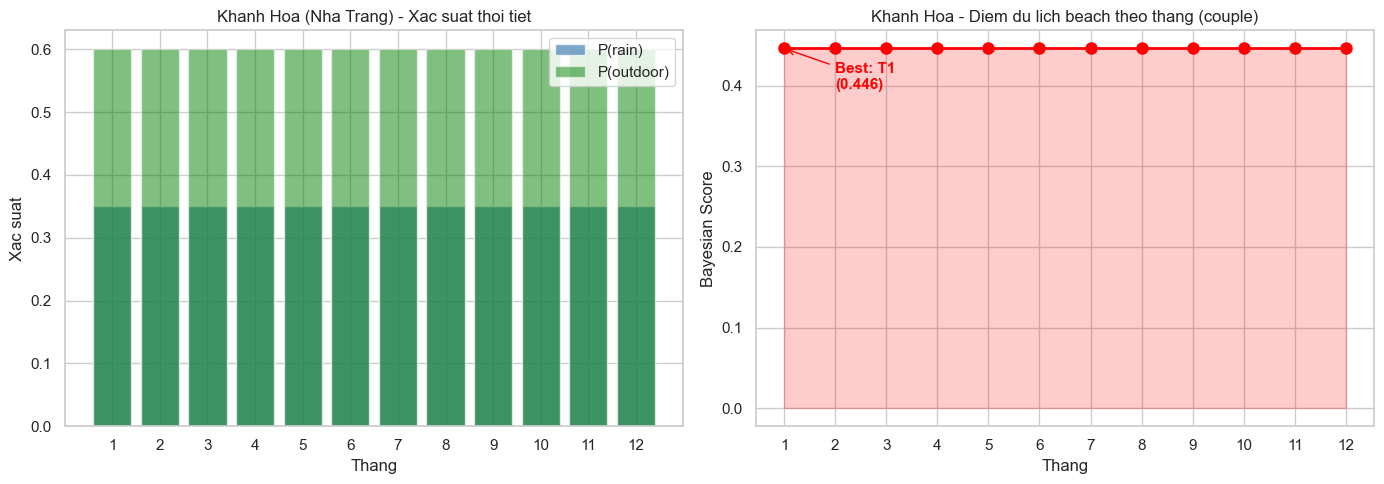

In [75]:
# Du doan thang tot nhat de du lich bien Nha Trang
best_months = bn.predict_best_month('Khanh Hoa', 'beach', 'couple')

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(best_months['month'], best_months['p_rain'], color='steelblue', alpha=0.7, label='P(rain)')
axes[0].bar(best_months['month'], best_months['p_outdoor'], color='green', alpha=0.5, label='P(outdoor)')
axes[0].set_xlabel('Thang')
axes[0].set_ylabel('Xac suat')
axes[0].set_title('Khanh Hoa (Nha Trang) - Xac suat thoi tiet')
axes[0].legend()
axes[0].set_xticks(range(1, 13))

axes[1].plot(best_months['month'], best_months['score'], 'ro-', linewidth=2, markersize=8)
axes[1].fill_between(best_months['month'], best_months['score'], alpha=0.2, color='red')
axes[1].set_xlabel('Thang')
axes[1].set_ylabel('Bayesian Score')
axes[1].set_title('Khanh Hoa - Diem du lich beach theo thang (couple)')
axes[1].set_xticks(range(1, 13))

best_m = best_months.loc[best_months['score'].idxmax(), 'month']
best_s = best_months['score'].max()
axes[1].annotate(f'Best: T{int(best_m)}\n({best_s:.3f})',
                 xy=(best_m, best_s), xytext=(best_m+1, best_s-0.05),
                 arrowprops=dict(arrowstyle='->', color='red'),
                 fontsize=11, fontweight='bold', color='red')

plt.tight_layout()
plt.savefig('data/processed/bayes_best_month.png', dpi=150, bbox_inches='tight')
plt.show()

### 6.2 Bayesian Scoring — Xếp hạng 30 điểm du lịch


📊 BAYESIAN SCORING — Tháng 3, Nhóm: couple
               place_name      category    province  p_rain  p_outdoor  p_user_like  bayesian_score
        Imperial City Hue       culture         Hue   0.514      0.787        0.772           0.795
       Vinpearl Nha Trang entertainment   Khanh Hoa   0.350      0.600        0.749           0.774
         My Son Sanctuary       culture   Quang Nam   0.350      0.600        0.749           0.774
          Bai Dinh Pagoda       culture   Ninh Binh   0.350      0.600        0.749           0.774
       Crazy House Da Lat       culture    Lam Dong   0.350      0.600        0.749           0.774
          Po Nagar Towers       culture   Khanh Hoa   0.350      0.600        0.749           0.774
      Hoi An Ancient Town       culture   Quang Nam   0.350      0.600        0.749           0.774
              Ba Na Hills entertainment     Da Nang   0.350      0.600        0.749           0.774
           Hoan Kiem Lake       culture      Ha Noi   0.

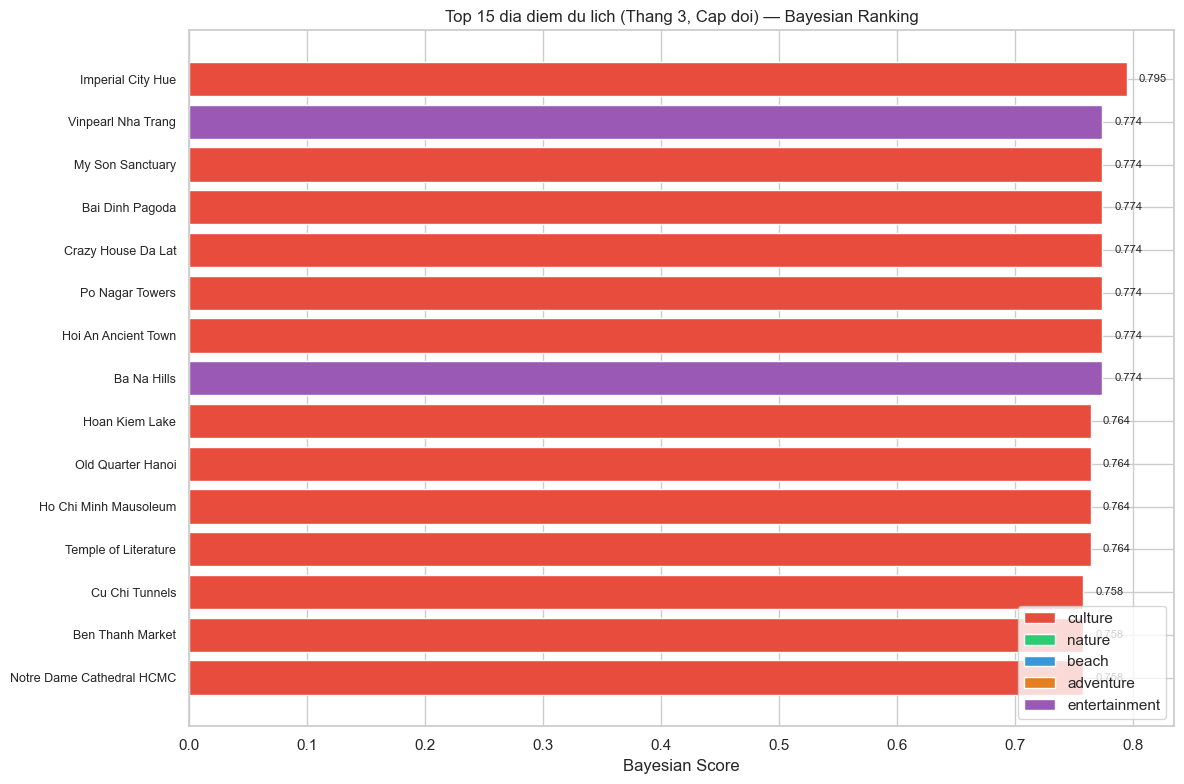

In [76]:
# Xep hang 30 diem du lich (thang 3, cap doi)
scored_places = bn.score_places(df_places, month=3, group_type='couple')

# Visualization - top 15
top15 = scored_places.head(15)
fig, ax = plt.subplots(figsize=(12, 8))
colors_map = {'culture': '#e74c3c', 'nature': '#2ecc71', 'beach': '#3498db',
          'adventure': '#e67e22', 'entertainment': '#9b59b6'}
bar_colors = [colors_map.get(c, '#95a5a6') for c in top15['category']]

bars = ax.barh(range(len(top15)), top15['bayesian_score'], color=bar_colors, edgecolor='white')
ax.set_yticks(range(len(top15)))
ax.set_yticklabels(top15['place_name'], fontsize=9)
ax.set_xlabel('Bayesian Score')
ax.set_title('Top 15 dia diem du lich (Thang 3, Cap doi) — Bayesian Ranking')
ax.invert_yaxis()

# Legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=v, label=k) for k, v in colors_map.items()]
ax.legend(handles=legend_elements, loc='lower right')

for i, (score, name) in enumerate(zip(top15['bayesian_score'], top15['place_name'])):
    ax.text(score + 0.01, i, f'{score:.3f}', va='center', fontsize=8)

plt.tight_layout()
plt.savefig('data/processed/bayes_place_ranking.png', dpi=150, bbox_inches='tight')
plt.show()

### 6.3 Tích hợp C+D — Full Pipeline

In [77]:
# Tich hop day du: Bayesian Network (D) + Knowledge Base (C)
# Kich ban: Gia dinh di Da Nang thang 8, budget 3M, thich beach & culture
result_cd, metadata = integrate_bayes_kb(
    places_df=df_places,
    province='Da Nang',
    month=8,
    group_type='family',
    budget_vnd=3_000_000,
    user_preferences=['beach', 'culture'],
    num_days=3,
    weather_probs_df=weather_probs,
    verbose=True,
)

🔗 TÍCH HỢP BAYESIAN NETWORK (D) + KNOWLEDGE BASE (C)

📊 Bước 1: Bayesian Network — Dự đoán thời tiết
--------------------------------------------------
[LOAD] Vietnam weather: 181,960 rows — /Users/nhanhoang/Desktop/Introduction-AI-Assignment/data/cleaned/vietnam_weather.csv
[BAYES NET] Xây dựng thành công: 5 nodes
  → rain: parents=['province', 'month'], CPT size=480
  → outdoor_suitable: parents=['province', 'month'], CPT size=480
  → hot: parents=['province', 'month'], CPT size=480
  → humid: parents=['province', 'month'], CPT size=480
  → user_like: parents=['category', 'group_type', 'is_rain'], CPT size=40

  Tỉnh: Da Nang, Tháng: 8
  P(rain)    = 0.350
  P(outdoor) = 0.600
  P(hot)     = 0.200
  P(humid)   = 0.400

🧠 Bước 2: Knowledge Base — Áp dụng luật IF-THEN
--------------------------------------------------
🧠 KNOWLEDGE BASE — FORWARD CHAINING INFERENCE

📋 Context: {'rain_mm': 5.25, 'temp_max': 30, 'temp_min': 22, 'humidity': 70, 'wind_speed': 10, 'budget_vnd': 3000000, 'grou

In [78]:
# Kich ban 2: Solo adventure tai Lam Dong thang 12
result_cd2, metadata2 = integrate_bayes_kb(
    places_df=df_places,
    province='Lam Dong',
    month=12,
    group_type='solo',
    budget_vnd=5_000_000,
    user_preferences=['adventure', 'nature'],
    num_days=4,
    weather_probs_df=weather_probs,
    verbose=True,
)

🔗 TÍCH HỢP BAYESIAN NETWORK (D) + KNOWLEDGE BASE (C)

📊 Bước 1: Bayesian Network — Dự đoán thời tiết
--------------------------------------------------
[LOAD] Vietnam weather: 181,960 rows — /Users/nhanhoang/Desktop/Introduction-AI-Assignment/data/cleaned/vietnam_weather.csv
[BAYES NET] Xây dựng thành công: 5 nodes
  → rain: parents=['province', 'month'], CPT size=480
  → outdoor_suitable: parents=['province', 'month'], CPT size=480
  → hot: parents=['province', 'month'], CPT size=480
  → humid: parents=['province', 'month'], CPT size=480
  → user_like: parents=['category', 'group_type', 'is_rain'], CPT size=40

  Tỉnh: Lam Dong, Tháng: 12
  P(rain)    = 0.350
  P(outdoor) = 0.600
  P(hot)     = 0.200
  P(humid)   = 0.400

🧠 Bước 2: Knowledge Base — Áp dụng luật IF-THEN
--------------------------------------------------
🧠 KNOWLEDGE BASE — FORWARD CHAINING INFERENCE

📋 Context: {'rain_mm': 5.25, 'temp_max': 30, 'temp_min': 22, 'humidity': 70, 'wind_speed': 10, 'budget_vnd': 5000000, 'gr

In [79]:
# Kich ban 3: Cap doi du lich Ha Noi thang 3
result_cd3, metadata3 = integrate_bayes_kb(
    places_df=df_places,
    province='Ha Noi',
    month=3,
    group_type='couple',
    budget_vnd=2_000_000,
    user_preferences=['culture'],
    num_days=2,
    weather_probs_df=weather_probs,
    verbose=True,
)

🔗 TÍCH HỢP BAYESIAN NETWORK (D) + KNOWLEDGE BASE (C)

📊 Bước 1: Bayesian Network — Dự đoán thời tiết
--------------------------------------------------
[LOAD] Vietnam weather: 181,960 rows — /Users/nhanhoang/Desktop/Introduction-AI-Assignment/data/cleaned/vietnam_weather.csv
[BAYES NET] Xây dựng thành công: 5 nodes
  → rain: parents=['province', 'month'], CPT size=480
  → outdoor_suitable: parents=['province', 'month'], CPT size=480
  → hot: parents=['province', 'month'], CPT size=480
  → humid: parents=['province', 'month'], CPT size=480
  → user_like: parents=['category', 'group_type', 'is_rain'], CPT size=40

  Tỉnh: Ha Noi, Tháng: 3
  P(rain)    = 0.270
  P(outdoor) = 0.916
  P(hot)     = 0.040
  P(humid)   = 0.273

🧠 Bước 2: Knowledge Base — Áp dụng luật IF-THEN
--------------------------------------------------
🧠 KNOWLEDGE BASE — FORWARD CHAINING INFERENCE

📋 Context: {'rain_mm': 4.057071960297767, 'temp_max': 30, 'temp_min': 22, 'humidity': 70, 'wind_speed': 10, 'budget_vnd': 20

In [80]:
# Tong ket C+D
print('=' * 70)
print('TONG KET THANH PHAN (C) + (D)')
print('=' * 70)
print()
print('(C) Knowledge Base - He luat IF-THEN:')
print(f'  So luat: {len(kb.rules)}')
print(f'  Phan loai: Thoi tiet (6), Ngan sach (2), Nhom du khach (3),')
print(f'             Mua (2), So thich (3), Thoi gian (2)')
print()
print('(D) Bayesian Network:')
print(f'  So nodes: {len(bn.nodes)}')
total_cpt = sum(len(n.cpt) for n in bn.nodes.values())
print(f'  Tong CPT entries: {total_cpt}')
print(f'  Cac bien: rain, outdoor_suitable, hot, humid, user_like')
print()
print('Tich hop C+D:')
print(f'  Pipeline: Bayes du doan thoi tiet -> IF-THEN loc dia diem -> Bayes scoring')
print(f'  Test 3 kich ban: Da Nang (gia dinh), Lam Dong (solo), Ha Noi (cap doi)')
print('=' * 70)

TONG KET THANH PHAN (C) + (D)

(C) Knowledge Base - He luat IF-THEN:
  So luat: 18
  Phan loai: Thoi tiet (6), Ngan sach (2), Nhom du khach (3),
             Mua (2), So thich (3), Thoi gian (2)

(D) Bayesian Network:
  So nodes: 5
  Tong CPT entries: 1960
  Cac bien: rain, outdoor_suitable, hot, humid, user_like

Tich hop C+D:
  Pipeline: Bayes du doan thoi tiet -> IF-THEN loc dia diem -> Bayes scoring
  Test 3 kich ban: Da Nang (gia dinh), Lam Dong (solo), Ha Noi (cap doi)


---
## 7. Component (E) — Machine Learning: Decision Tree + Naive Bayes

**Mục tiêu:**
- Decision Tree phân loại người dùng thành nhóm du khách (culture_lover, adventure_seeker, foodie...) dựa trên 24 category ratings
- Naive Bayes (MultinomialNB) dự đoán sentiment review khách sạn từ text (TF-IDF)
- Tích hợp kết quả ML vào planner pipeline

### 7.1 Decision Tree — Phân loại nhóm du khách

Sử dụng `travel_ratings_clustered.csv` (5,456 users):
- **Features (X):** 24 category ratings (Churches, Resorts, Beaches, ...)
- **Target (y):** cluster labels 0-4 (từ KMeans ở Section 4.5)
- **Mục đích:** Đặt tên có ý nghĩa cho mỗi cluster → phân loại user mới

In [ ]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler

# =============================================
# 7.1a — Phan tich cluster centroids & dat ten
# =============================================

# 24 cot rating (loai bo Unnamed: 25 va metadata)
RATING_COLUMNS = [
    'Churches', 'Resorts', 'Beaches', 'Parks', 'Theatres', 'Museums',
    'Malls', 'Zoo', 'Restaurants', 'Pubs_Bars', 'Local_Services',
    'Burger_Pizza', 'Hotels', 'Juice_Bars', 'Art_Galleries',
    'Dance_Clubs', 'Swimming_Pools', 'Gyms', 'Bakeries', 'Beauty_Spas',
    'Cafes', 'View_Points', 'Monuments', 'Gardens',
]

# Mapping nhom category -> traveler type
CATEGORY_TO_TYPE_HINTS = {
    'culture_lover':        {'Churches', 'Museums', 'Monuments', 'Art_Galleries', 'Theatres'},
    'nature_explorer':      {'Parks', 'View_Points', 'Gardens', 'Zoo'},
    'beach_relaxer':        {'Beaches', 'Resorts', 'Swimming_Pools'},
    'foodie':               {'Restaurants', 'Cafes', 'Bakeries', 'Pubs_Bars', 'Burger_Pizza', 'Juice_Bars'},
    'entertainment_seeker': {'Dance_Clubs', 'Gyms', 'Beauty_Spas', 'Swimming_Pools'},
    'social_explorer':      {'Malls', 'Pubs_Bars', 'Local_Services', 'Hotels', 'Zoo'},
}

# Mapping traveler type -> user_preferences cho planner
TRAVELER_TYPE_TO_PREFERENCES = {
    'culture_lover':        ['culture'],
    'nature_explorer':      ['nature', 'adventure'],
    'beach_relaxer':        ['beach', 'nature'],
    'foodie':               ['culture', 'entertainment'],
    'entertainment_seeker': ['entertainment'],
    'social_explorer':      ['culture', 'entertainment'],
}

# Load data (reload clustered version)
df_ml = pd.read_csv(os.path.join(CLEANED_DIR, 'travel_ratings_clustered.csv'))
print(f'Data shape: {df_ml.shape}')
print(f'Cluster distribution:\n{df_ml["cluster"].value_counts().sort_index()}\n')

# Phan tich centroids
cluster_means = df_ml.groupby('cluster')[RATING_COLUMNS].mean()

# Dat ten cho moi cluster dua tren top categories
cluster_names = {}
used_names = set()

for cl in sorted(cluster_means.index):
    top5 = cluster_means.loc[cl].nlargest(5).index.tolist()
    print(f'Cluster {cl} \u2014 Top 5: {top5}')

    # Dem overlap voi moi type hint
    best_type = None
    best_score = 0
    for type_name, cat_set in CATEGORY_TO_TYPE_HINTS.items():
        overlap = len(set(top5) & cat_set)
        if overlap > best_score and type_name not in used_names:
            best_score = overlap
            best_type = type_name

    if best_type is None:
        best_type = f'traveler_type_{cl}'

    cluster_names[cl] = best_type
    used_names.add(best_type)
    print(f'  -> {best_type} (overlap={best_score})\n')

print('Cluster name mapping:')
for cl, name in cluster_names.items():
    print(f'  {cl}: {name}')

In [ ]:
# =============================================
# 7.1b — Visualize cluster profiles (bar chart)
# =============================================

fig, axes = plt.subplots(1, 5, figsize=(25, 5), sharey=True)
for idx, cl in enumerate(sorted(cluster_means.index)):
    ax = axes[idx]
    vals = cluster_means.loc[cl]
    top10 = vals.nlargest(10)
    ax.barh(range(len(top10)), top10.values, color=plt.cm.tab10(idx))
    ax.set_yticks(range(len(top10)))
    ax.set_yticklabels(top10.index, fontsize=8)
    ax.set_title(f'Cluster {cl}\n{cluster_names[cl]}', fontsize=10)
    ax.set_xlim(0, vals.max() * 1.1)

plt.suptitle('Top 10 Category Ratings per Cluster', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('data/processed/cluster_profiles.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# =============================================
# 7.1c — Train Decision Tree Classifier
# =============================================

X = df_ml[RATING_COLUMNS].values
y = df_ml['cluster'].values

# Map cluster IDs -> traveler type names cho y labels
y_named = pd.Series(y).map(cluster_names).values

# Standardize features
scaler_dt = StandardScaler()
X_scaled = scaler_dt.fit_transform(X)

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_named, test_size=0.2, random_state=42, stratify=y_named
)

print(f'Train: {len(X_train)}, Test: {len(X_test)}')

# Train Decision Tree
dt_model = DecisionTreeClassifier(
    max_depth=8,
    min_samples_leaf=10,
    random_state=42,
    criterion='gini'
)
dt_model.fit(X_train, y_train)

# Evaluate
y_pred = dt_model.predict(X_test)
dt_accuracy = accuracy_score(y_test, y_pred)

print(f'\nDecision Tree Accuracy: {dt_accuracy:.4f} ({dt_accuracy:.1%})')
print(f'\nClassification Report:')
print(classification_report(y_test, y_pred))

In [ ]:
# =============================================
# 7.1d — Feature Importance & Tree Visualization
# =============================================

# Feature importance
importances = pd.DataFrame({
    'feature': RATING_COLUMNS,
    'importance': dt_model.feature_importances_
}).sort_values('importance', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# Bar chart top 10
ax1 = axes[0]
top10_imp = importances.head(10)
ax1.barh(range(len(top10_imp)), top10_imp['importance'].values, color='steelblue')
ax1.set_yticks(range(len(top10_imp)))
ax1.set_yticklabels(top10_imp['feature'].values)
ax1.set_xlabel('Importance')
ax1.set_title('Top 10 Feature Importance (Decision Tree)')
ax1.invert_yaxis()

# Decision Tree structure (max_depth=3 cho de doc)
ax2 = axes[1]
plot_tree(dt_model, max_depth=3, feature_names=RATING_COLUMNS,
          class_names=sorted(set(y_named)), filled=True, rounded=True,
          fontsize=6, ax=ax2)
ax2.set_title('Decision Tree Structure (depth=3)')

plt.tight_layout()
plt.savefig('data/processed/dt_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nTop 10 features:')
print(importances.head(10).to_string(index=False))

In [ ]:
# =============================================
# 7.1e — Classify sample users
# =============================================

# Tao 3 user mau voi rating profiles khac nhau
sample_users = {
    'Van hoa enthusiast': {
        'Churches': 4.5, 'Museums': 4.8, 'Monuments': 4.2, 'Art_Galleries': 4.0,
        'Theatres': 3.5, 'Beaches': 1.0, 'Resorts': 0.5, 'Parks': 2.0,
        'Restaurants': 2.0, 'Cafes': 1.5, 'Malls': 1.0, 'Zoo': 1.0,
        'Pubs_Bars': 0.5, 'Local_Services': 1.0, 'Burger_Pizza': 1.0,
        'Hotels': 2.0, 'Juice_Bars': 0.5, 'Dance_Clubs': 0.0,
        'Swimming_Pools': 0.0, 'Gyms': 0.0, 'Bakeries': 1.0,
        'Beauty_Spas': 0.0, 'View_Points': 2.0, 'Gardens': 2.5,
    },
    'Beach lover': {
        'Churches': 0.5, 'Museums': 1.0, 'Monuments': 0.5, 'Art_Galleries': 0.5,
        'Theatres': 1.0, 'Beaches': 5.0, 'Resorts': 4.5, 'Parks': 2.0,
        'Restaurants': 2.5, 'Cafes': 2.0, 'Malls': 1.5, 'Zoo': 1.0,
        'Pubs_Bars': 3.0, 'Local_Services': 1.0, 'Burger_Pizza': 2.0,
        'Hotels': 3.0, 'Juice_Bars': 2.0, 'Dance_Clubs': 2.0,
        'Swimming_Pools': 4.0, 'Gyms': 1.0, 'Bakeries': 1.0,
        'Beauty_Spas': 2.0, 'View_Points': 3.0, 'Gardens': 1.0,
    },
    'Foodie traveler': {
        'Churches': 1.0, 'Museums': 1.5, 'Monuments': 1.0, 'Art_Galleries': 1.0,
        'Theatres': 2.0, 'Beaches': 2.0, 'Resorts': 1.5, 'Parks': 2.0,
        'Restaurants': 5.0, 'Cafes': 4.5, 'Malls': 3.0, 'Zoo': 1.0,
        'Pubs_Bars': 4.0, 'Local_Services': 2.0, 'Burger_Pizza': 4.5,
        'Hotels': 2.5, 'Juice_Bars': 3.5, 'Dance_Clubs': 2.0,
        'Swimming_Pools': 1.0, 'Gyms': 1.0, 'Bakeries': 4.0,
        'Beauty_Spas': 1.5, 'View_Points': 1.0, 'Gardens': 1.0,
    },
}

print('=' * 70)
print('PHAN LOAI USER MOI BANG DECISION TREE')
print('=' * 70)

for name, ratings in sample_users.items():
    # Tao feature vector theo dung thu tu RATING_COLUMNS
    X_user = np.array([[ratings.get(col, 0.0) for col in RATING_COLUMNS]])
    X_user_scaled = scaler_dt.transform(X_user)

    # Predict
    predicted_type = dt_model.predict(X_user_scaled)[0]
    prefs = TRAVELER_TYPE_TO_PREFERENCES.get(predicted_type, ['culture'])

    print(f'\n  User: {name}')
    print(f'  -> Traveler type: {predicted_type}')
    print(f'  -> User preferences (for planner): {prefs}')

### 7.2 Naive Bayes — Phân loại sentiment review khách sạn

Sử dụng `hotel_reviews.csv` (515K reviews):
- **Features (X):** TF-IDF vectors từ `full_review` (5,000 features, unigrams + bigrams)
- **Target (y):** `sentiment_binary` (0 = negative khi score < 7, 1 = positive khi score >= 7)
- **Model:** MultinomialNB (Naive Bayes cho dữ liệu đếm/TF-IDF)

In [ ]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.feature_extraction.text import TfidfVectorizer

# =============================================
# 7.2a — Chuan bi du lieu & Train Naive Bayes
# =============================================

# Lay sample reviews (tiet kiem RAM)
review_data = df_reviews[['full_review', 'sentiment_binary', 'Reviewer_Score']].dropna()
review_data = review_data[review_data['full_review'].str.len() > 20]

SAMPLE_SIZE = 50000
if len(review_data) > SAMPLE_SIZE:
    review_data = review_data.sample(SAMPLE_SIZE, random_state=42)

print(f'Sample size: {len(review_data):,} reviews')
print(f'Sentiment distribution:\n{review_data["sentiment_binary"].value_counts()}')

# TF-IDF vectorization
tfidf_nb = TfidfVectorizer(max_features=5000, stop_words='english', ngram_range=(1, 2))
X_reviews = tfidf_nb.fit_transform(review_data['full_review'])
y_reviews = review_data['sentiment_binary'].values

print(f'\nTF-IDF matrix: {X_reviews.shape}')

# Train/test split
X_train_nb, X_test_nb, y_train_nb, y_test_nb = train_test_split(
    X_reviews, y_reviews, test_size=0.2, random_state=42, stratify=y_reviews
)

print(f'Train: {X_train_nb.shape[0]:,}, Test: {X_test_nb.shape[0]:,}')

# Train Naive Bayes
nb_model = MultinomialNB(alpha=1.0)
nb_model.fit(X_train_nb, y_train_nb)

# Evaluate
y_pred_nb = nb_model.predict(X_test_nb)
nb_accuracy = accuracy_score(y_test_nb, y_pred_nb)

print(f'\nNaive Bayes Accuracy: {nb_accuracy:.4f} ({nb_accuracy:.1%})')
print(f'\nClassification Report:')
print(classification_report(y_test_nb, y_pred_nb,
                           target_names=['Negative (< 7)', 'Positive (>= 7)']))

In [ ]:
# =============================================
# 7.2b — Confusion Matrix & Top TF-IDF Features
# =============================================

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Confusion matrix heatmap
cm = confusion_matrix(y_test_nb, y_pred_nb)
ax1 = axes[0]
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax1,
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'])
ax1.set_xlabel('Predicted')
ax1.set_ylabel('Actual')
ax1.set_title(f'Naive Bayes Confusion Matrix\n(Accuracy: {nb_accuracy:.1%})')

# Top features cho moi class
feature_names = tfidf_nb.get_feature_names_out()
log_probs = nb_model.feature_log_prob_

ax2 = axes[1]
# Top 10 tu/cum tu "positive" nhat (class 1) va "negative" nhat (class 0)
top_pos_idx = np.argsort(log_probs[1] - log_probs[0])[-10:]
top_neg_idx = np.argsort(log_probs[0] - log_probs[1])[-10:]

top_words = ([feature_names[i] for i in top_neg_idx] +
             [feature_names[i] for i in top_pos_idx])
top_scores = ([log_probs[0][i] - log_probs[1][i] for i in top_neg_idx] +
              [log_probs[1][i] - log_probs[0][i] for i in top_pos_idx])
colors_bar = ['#e74c3c'] * 10 + ['#2ecc71'] * 10

ax2.barh(range(20), top_scores, color=colors_bar)
ax2.set_yticks(range(20))
ax2.set_yticklabels(top_words, fontsize=8)
ax2.set_xlabel('Log probability difference')
ax2.set_title('Top Negative (red) vs Positive (green) Keywords')
ax2.axvline(x=0, color='gray', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('data/processed/nb_sentiment_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# =============================================
# 7.2c — Du doan sentiment cho review mau
# =============================================

sample_reviews_text = [
    "The hotel was amazing, beautiful room with a great view. Staff was incredibly friendly and helpful. Best stay ever!",
    "Terrible experience. Room was dirty, noisy all night, and the staff was rude. Would never come back.",
    "Average hotel, nothing special. Location was okay but room was small. Breakfast was decent.",
    "Loved everything about this place! Perfect location, clean rooms, excellent breakfast buffet.",
    "The worst hotel I have ever stayed in. Bed bugs, broken air conditioning, and no hot water.",
]

print('=' * 70)
print('DU DOAN SENTIMENT REVIEW (Naive Bayes)')
print('=' * 70)

for review in sample_reviews_text:
    X_sample = tfidf_nb.transform([review])
    pred = nb_model.predict(X_sample)[0]
    proba = nb_model.predict_proba(X_sample)[0]
    sentiment = 'Positive' if pred == 1 else 'Negative'
    confidence = max(proba)

    print(f'\n  Review: "{review[:80]}..."')
    print(f'  -> Sentiment: {sentiment} (confidence: {confidence:.1%})')
    print(f'     P(negative)={proba[0]:.3f}, P(positive)={proba[1]:.3f}')

### 7.3 Tích hợp ML → Planner Pipeline

**Pipeline hoàn chỉnh:**
1. User nhập ratings cho 24 loại hình → Decision Tree phân loại → traveler_type
2. traveler_type → mapping → `user_preferences` (culture, beach, adventure, ...)
3. `user_preferences` truyền vào `planner.plan_trip()` → lịch trình tối ưu

In [ ]:
# =============================================
# 7.3 — Tich hop ML vao Planner Pipeline
# =============================================
from modules.planner import plan_trip

# Buoc 1: User moi nhap ratings
user_ratings_demo = {
    'Churches': 4.0, 'Museums': 4.5, 'Monuments': 4.0, 'Art_Galleries': 3.5,
    'Theatres': 3.0, 'Beaches': 2.0, 'Resorts': 1.0, 'Parks': 3.0,
    'Restaurants': 2.5, 'Cafes': 2.0, 'Malls': 1.5, 'Zoo': 1.0,
    'Pubs_Bars': 1.0, 'Local_Services': 1.0, 'Burger_Pizza': 1.5,
    'Hotels': 2.0, 'Juice_Bars': 1.0, 'Dance_Clubs': 0.5,
    'Swimming_Pools': 0.5, 'Gyms': 0.5, 'Bakeries': 1.5,
    'Beauty_Spas': 0.5, 'View_Points': 3.0, 'Gardens': 3.0,
}

# Buoc 2: Decision Tree phan loai
X_demo = np.array([[user_ratings_demo.get(col, 0.0) for col in RATING_COLUMNS]])
X_demo_scaled = scaler_dt.transform(X_demo)
predicted_type = dt_model.predict(X_demo_scaled)[0]
user_prefs = TRAVELER_TYPE_TO_PREFERENCES.get(predicted_type, ['culture'])

print('=' * 70)
print('TICH HOP ML -> PLANNER')
print('=' * 70)
print(f'\n  Buoc 1: Decision Tree phan loai user')
print(f'    -> Traveler type: {predicted_type}')
print(f'    -> User preferences: {user_prefs}')

# Buoc 3: Goi planner voi preferences tu ML
print(f'\n  Buoc 2: Goi plan_trip() voi user_preferences={user_prefs}')
print('=' * 70)

result_ml = plan_trip(
    province='Da Nang',
    month=3,
    group_type='couple',
    budget_vnd=3_000_000,
    user_preferences=user_prefs,
    num_days=3,
    verbose=True,
)

In [ ]:
# =============================================
# 7.4 — Tong ket Component (E)
# =============================================
print('=' * 70)
print('TONG KET THANH PHAN (E) — MACHINE LEARNING')
print('=' * 70)
print()
print('(E1) Decision Tree — Phan loai nhom du khach:')
print(f'  Model: DecisionTreeClassifier (max_depth=8)')
print(f'  Data: {len(df_ml):,} users, {len(RATING_COLUMNS)} features')
print(f'  Clusters: {len(cluster_names)} nhom')
for cl, name in cluster_names.items():
    count = (df_ml["cluster"] == cl).sum()
    print(f'    {cl}: {name} ({count:,} users)')
print(f'  Accuracy: {dt_accuracy:.1%}')
print(f'  Top 3 features: {importances.head(3)["feature"].tolist()}')
print()
print('(E2) Naive Bayes — Phan loai sentiment review:')
print(f'  Model: MultinomialNB (alpha=1.0)')
print(f'  Data: {SAMPLE_SIZE:,} reviews, TF-IDF {X_reviews.shape[1]} features')
print(f'  Accuracy: {nb_accuracy:.1%}')
print()
print('(E3) Tich hop:')
print(f'  User ratings -> Decision Tree -> traveler_type -> user_preferences')
print(f'  user_preferences -> planner.plan_trip() -> lich trinh toi uu')
print('=' * 70)

---
## 8. Summary of Processed Data

In [81]:
print('=' * 70)
print('TONG KET DU LIEU DA XU LY')
print('=' * 70)

# Kiem tra cleaned files
print('\n--- Cleaned Data ---')
for root, dirs, files in os.walk(CLEANED_DIR):
    for f in sorted(files):
        fpath = os.path.join(root, f)
        size_mb = os.path.getsize(fpath) / (1024*1024)
        if f.endswith('.csv'):
            nrows = sum(1 for _ in open(fpath)) - 1
            print(f'  {f:40s} {size_mb:8.2f} MB   {nrows:>10,} rows')
        else:
            print(f'  {f:40s} {size_mb:8.2f} MB')

# Kiem tra feature files
print('\n--- Feature Files ---')
for root, dirs, files in os.walk(FEATURES_DIR):
    for f in sorted(files):
        fpath = os.path.join(root, f)
        size_mb = os.path.getsize(fpath) / (1024*1024)
        if f.endswith('.npy'):
            arr = np.load(fpath)
            print(f'  {f:40s} {size_mb:8.2f} MB   shape: {arr.shape}')
        elif f.endswith('.npz'):
            print(f'  {f:40s} {size_mb:8.2f} MB   (sparse matrix)')
        else:
            print(f'  {f:40s} {size_mb:8.2f} MB')

# Kiem tra processed images
print('\n--- EDA Plots ---')
for root, dirs, files in os.walk(PROCESSED_DIR):
    for f in sorted(files):
        if f.endswith('.png'):
            fpath = os.path.join(root, f)
            size_kb = os.path.getsize(fpath) / 1024
            print(f'  {f:40s} {size_kb:8.1f} KB')

print('\n' + '=' * 70)
print('HOAN TAT QUY TRINH XU LY DU LIEU')
print('=' * 70)

TONG KET DU LIEU DA XU LY

--- Cleaned Data ---
  .gitkeep                                     0.00 MB
  hotel_bookings.csv                          20.31 MB      118,565 rows
  hotel_reviews.csv                          333.99 MB      515,738 rows
  travel_ratings.csv                           0.90 MB        5,456 rows
  travel_ratings_clustered.csv                 0.91 MB        5,456 rows
  vietnam_weather.csv                         13.60 MB      181,960 rows
  world_cities.csv                             0.46 MB          560 rows

--- Feature Files ---
  .gitkeep                                     0.00 MB
  cost_matrix.npy                              0.01 MB   shape: (30, 30)
  distance_matrix.npy                          0.01 MB   shape: (30, 30)
  review_labels.npy                            0.38 MB   shape: (50000,)
  review_scores.npy                            0.38 MB   shape: (50000,)
  review_tfidf.npz                             8.52 MB   (sparse matrix)
  tfidf_features

---
## Data Mapping → AI Components

| Feature File | AI Component | Description |
|---|---|---|
| `distance_matrix.npy` | **(A) A\* Search** | Distance matrix for 30 Vietnam tourist spots |
| `cost_matrix.npy` | **(A) Search** + **(B) CSP** | Travel cost matrix (VND) |
| `travel_time_matrix.npy` | **(A) Search** + **(B) CSP** | Travel time matrix (hours) |
| `vn_tourist_places.csv` | **(A)(B)(C)** | Place info with province descriptions (96% coverage) |
| `vietnam_weather.csv` | **(C) IF-THEN** + **(D) Bayes** | Weather data — 181K rows, 40 provinces |
| `weather_probabilities.csv` | **(D) Bayesian Network** | P(rain \| province, month) — 480 rows |
| `vn_climate_monthly.csv` | **(B) CSP** + **(D) Bayes** | Monthly climate stats from real 181K records |
| `hotel_price_stats.csv` | **(B) CSP** | Hotel budget constraints by province × tier |
| `agoda_hotels_vn.csv` | **(B) CSP** | Cleaned Agoda hotel ratings — 78 VN hotels |
| `agoda_hotel_prices_vn.csv` | **(B) CSP** | Cleaned Agoda nightly prices — 69 listings |
| `hotel_reviews.csv` | **(E) ML** | Cleaned 515K reviews with sentiment labels |
| `travel_ratings.csv` | **(E) ML** | 24 category ratings (5,456 users) |
| `hotel_bookings.csv` | **(B) CSP** | Budget, stay duration, and booking constraints (119K) |
| `world_cities.csv` | **(A)(C)** | City ratings + climate (560 cities) |
| `review_tfidf.npz` | **(E) ML** | TF-IDF sparse matrix (50K × 5K features) |
| `user_features.npy` | **(E) ML** | Scaled user rating feature vectors |
| `user_cluster_labels.npy` | **(E) ML** | KMeans cluster labels (5 traveler types) |
